# EDA exhaustivo sobre **dev** · Ford FIC III

Exploración profunda de las tres tablas crudas y de la unión a nivel vehículo,
**restringida a los 864 vehículos de dev**. Es el paso previo a F2: acá se mira el
dato, no se construye el panel.

Tres cosas que conviene tener claras antes de leer un solo número:

1. **Esto no es F2.** `scripts/build_dataset.py` es todavía un
   `NotImplementedError`: no existe `panel.parquet` ni ninguna feature `feat_*` de
   ventana. Lo que hay son los seis CSV de `data/raw/` y la unión a nivel vehículo
   que dejó `scripts/make_test_split.py`. Acá **no** se define W, G, H ni Δ.
2. **Todo sale del holdout congelado.** Los 217 vehículos de test no entran en
   ningún cómputo, ni siquiera para calcular una media. La guarda no es un
   comentario: después de armar cada tabla corre `check_dev_only()`, que falla
   ruidosamente si algo de test se coló (§0.2).
3. **La cohorte ES la etiqueta.** `IdentificationDate` nula ⇔ sin evento
   (`docs/memoria/f1-datos-reales.md`). Nunca entra como feature, y `cohort`
   tampoco.

Los datos los sirve `scripts/build_eda_cache.py`, que hace **una** pasada por los
crudos canonizando y filtrando a dev, y deja parquet reusables en
`experiments/eda/dev/`. El dashboard (`scripts/dashboard_eda.py`) lee exactamente
ese cache: el filtro dev se decide en un solo lugar.

## Índice

| § | Qué contesta |
|---|---|
| 0 | Setup, holdout y la guarda dev-only |
| 1 | Diccionario de datos: CSV real vs. `raw_sources.yaml` vs. PDF oficial |
| 2 | Estáticas y el sesgo de `ENG_3` dentro de dev |
| 3 | Etiqueta, anclaje temporal y supervivencia |
| 4 | Calidad del eje de odómetro |
| 5 | Uso y contexto (`trips`) |
| 6 | Severidad y postratamiento (`signals` + las dos columnas nuevas) |
| 7 | Correlaciones, con el caveat de la regla 6 |
| 8 | Análisis temporal |
| 9 | Factibilidad de las features del plan §4 |
| 10 | Síntesis para quien implemente F2 |

## 0 · Setup

### 0.1 · Qué se carga y de dónde

Nada de paths a mano: todo pasa por `src/config.py` (`load_config`,
`resolve_path`). El universo de dev sale de `data/processed/test_split.json`
—congelado el 2026-09-16, semilla 42— y los datos del cache dev-only.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lifelines import KaplanMeierFitter
from lifelines.statistics import multivariate_logrank_test
from scipy.stats import mannwhitneyu, spearmanr

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO))

from src.config import load_config, resolve_path, set_seed
from src.data.dedupe import canonical_map
from src.data.loader import load_sources_config
from src.eval.splits import load_test_split
from scripts.build_eda_cache import (
    ALERT_RED,
    BLUE,
    CATEGORICAL,
    COHORT_COLORS,
    COHORT_LABELS,
    FORD_BLUE,
    INK,
    SEQUENTIAL,
    MISSING_FAMILIES,
    PDF_COLUMNS,
    cache_dir,
    cache_exists,
    dictionary_comparison,
    feature_feasibility,
    load_eda_cache,
    raw_columns,
    vehicle_matrix,
)

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.max_rows", 120)

CONFIG = "configs/data/eda_cache.yaml"
cfg = load_config(CONFIG)
set_seed(int(cfg["seed"]))

split = load_test_split(cfg["test_split"])
DEV_VEHICLES = set(split["dev_vehicles"])
TEST_VEHICLES = set(split["test_vehicles"])
CLONES = canonical_map(cfg["dedupe"])

print(f"holdout congelado el {split['created_at']} (semilla {split['seed']})")
print(f"dev : {len(DEV_VEHICLES):>5} vehículos  ({split['dev']['n_event_vehicles']} con evento, "
      f"tasa {split['dev']['event_rate']:.4f})")
print(f"test: {len(TEST_VEHICLES):>5} vehículos  -> NO se tocan en todo el notebook")
print(f"clones canonizados: {len(CLONES)} códigos -> {len(set(CLONES.values()))} vehículos")

holdout congelado el 2026-09-16T03:10:51+00:00 (semilla 42)
dev :   864 vehículos  (292 con evento, tasa 0.3380)
test:   217 vehículos  -> NO se tocan en todo el notebook
clones canonizados: 13 códigos -> 13 vehículos


### 0.2 · La guarda dev-only

`test_split.json` guarda `vehicle_id` **ya canónicos**. Los CSV crudos todavía
traen los 26 `VehicleCode` sin canonizar, así que el orden importa y es siempre el
mismo:

```python
chunk["VehicleCode"] = chunk["VehicleCode"].replace(mapping)   # 1) canonizar
chunk_dev = chunk[chunk["VehicleCode"].isin(dev_vehicles)]      # 2) recién ahí, dev
```

Al revés, las filas del código clon descartado (`VEH_0345`) no matchean ninguna id
de la lista —que solo tiene `VEH_0344`— y desaparecen sin ruido. No es leakage,
pero sí un error de conteo invisible.

Eso ya lo hace `scripts/build_eda_cache.py`. Lo que hace este notebook es
**verificarlo**, tabla por tabla: `check_dev_only()` corre después de armar cada
tabla grande y levanta `AssertionError` si aparece un solo vehículo de test.

In [2]:
def check_dev_only(frame: pd.DataFrame, nombre: str, *, id_col: str = "vehicle_id") -> pd.DataFrame:
    '''Falla ruidosamente si alguna fila de test se coló. Devuelve la tabla para encadenar.'''
    if id_col not in frame.columns:
        raise KeyError(f"`{nombre}` no tiene `{id_col}`: la guarda no se puede verificar")
    ids = set(frame[id_col].astype(str).unique())
    intrusos = ids & TEST_VEHICLES
    assert not intrusos, (
        f"`{nombre}`: {len(intrusos)} vehículo(s) de TEST en una tabla de dev "
        f"(ej.: {sorted(intrusos)[:3]})"
    )
    fuera = ids - DEV_VEHICLES
    assert not fuera, f"`{nombre}`: {len(fuera)} vehículo(s) fuera del universo de dev"
    print(f"  [ok] {nombre:<24} {len(frame):>8} filas · {len(ids):>4} vehículos · 0 de test")
    return frame


if not cache_exists(CONFIG):
    raise SystemExit(
        "No hay cache del EDA. Construilo con:\n"
        "    python scripts/build_eda_cache.py --config configs/data/eda_cache.yaml"
    )

cache = load_eda_cache(CONFIG)
META = cache["meta"]

print("Guarda dev-only sobre cada tabla del cache:")
for nombre, tabla in cache.items():
    if isinstance(tabla, pd.DataFrame) and "vehicle_id" in tabla.columns:
        check_dev_only(tabla, nombre)

Guarda dev-only sobre cada tabla del cache:
  [ok] vehicles_dev                  864 filas ·  864 vehículos · 0 de test
  [ok] trips_agg_dev                 864 filas ·  864 vehículos · 0 de test
  [ok] signals_agg_dev               864 filas ·  864 vehículos · 0 de test
  [ok] severity_scopes_dev          2592 filas ·  864 vehículos · 0 de test
  [ok] message_counts_dev           7225 filas ·  864 vehículos · 0 de test
  [ok] airfilter_counts_dev         4188 filas ·  864 vehículos · 0 de test
  [ok] trips_sample_dev           250000 filas ·  864 vehículos · 0 de test
  [ok] signals_sample_dev         250000 filas ·  864 vehículos · 0 de test
  [ok] probe_trips_dev             17074 filas ·    8 vehículos · 0 de test
  [ok] probe_signals_dev           63659 filas ·    8 vehículos · 0 de test


In [3]:
# La tabla sobre la que corre casi todo el notebook: una fila por vehículo de dev,
# con las estáticas, la etiqueta y todos los agregados de `trips` y `signals`.
veh = check_dev_only(vehicle_matrix(cache), "vehicle_matrix")

print(f"\n{veh.shape[0]} vehículos x {veh.shape[1]} columnas")
print(f"con evento: {int(veh['event_observed'].sum())} · tasa {veh['event_observed'].mean():.4f}")
print(f"\ncache construido el {META['created_at']} · semilla {META['seed']} · alcance {META['scope']}")
veh[["vehicle_id", "event_observed", "static_Engine", "static_ModelSeries", "n_trips", "n_signals", "trip_odo_max"]].head(3)

  [ok] vehicle_matrix                864 filas ·  864 vehículos · 0 de test

864 vehículos x 95 columnas
con evento: 292 · tasa 0.3380

cache construido el 2026-09-17T01:01:30+00:00 · semilla 42 · alcance dev-only


,vehicle_id,event_observed,static_Engine,static_ModelSeries,n_trips,n_signals,trip_odo_max
0,VEH_0001,0,ENG_1,MODEL_4,5983,18687,36383.0
1,VEH_0002,0,ENG_1,MODEL_4,82,138,39.0
2,VEH_0003,0,ENG_1,MODEL_4,2017,6856,10360.0


### 0.3 · Estilo de las figuras

Paleta anclada al azul Ford de `src/eval/plots.py` (`#1c3f94`). Como marca de
datos se usa el escalón `#2c52a8`, que es el del mismo tono dentro de la banda de
luminosidad que exige el validador de paletas; el `#1c3f94` de marca queda para
tinta de títulos. El rojo es el `ALERT_RED` del repo.

La paleta pasa los seis chequeos del validador (peor par adyacente: ΔE 9,1 bajo
simulación de daltonismo, 19,6 en visión normal). Casi todo el EDA tiene **dos**
series —la cohorte es la etiqueta—, así que el par azul/rojo es el caso normal y
siempre lleva leyenda.

In [4]:
mpl.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": INK["muted"],
    "axes.labelcolor": INK["secondary"],
    "axes.titlecolor": INK["primary"],
    "axes.titlesize": 11,
    "axes.titleweight": "semibold",
    "axes.labelsize": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": INK["grid"],
    "grid.linewidth": 0.7,
    "xtick.color": INK["muted"],
    "ytick.color": INK["muted"],
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.frameon": False,
    "legend.fontsize": 8,
    "font.family": "sans-serif",
    "font.sans-serif": ["Segoe UI", "DejaVu Sans"],
    "figure.dpi": 110,
    "savefig.dpi": 110,
})
sns.set_palette(list(CATEGORICAL))

COHORT_ORDER = [0, 1]


def cohort_hist(ax, hist, metric, *, titulo=None, xlabel=None, logy=False):
    '''Histograma EXACTO por cohorte (frecuencia relativa, no conteo: los grupos difieren).'''
    data = hist[hist["metric"].eq(metric)]
    for flag in COHORT_ORDER:
        side = data[data["event_observed"].eq(flag)]
        if side.empty:
            continue
        centro = (side["bin_left"] + side["bin_right"]) / 2
        ax.step(centro, side["frac"], where="mid", color=COHORT_COLORS[flag], lw=2,
                label=COHORT_LABELS[flag])
        ax.fill_between(centro, side["frac"], step="mid", color=COHORT_COLORS[flag], alpha=0.12)
    ax.set_title(titulo or metric)
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel("fracción de viajes")
    if logy:
        ax.set_yscale("log")
    ax.legend(loc="upper right")
    return ax


def cohort_box(ax, frame, column, *, titulo=None, ylabel=None, logy=False, showfliers=False):
    '''Boxplot por cohorte de un agregado **por vehículo** (un punto = un vehículo).'''
    grupos = [frame.loc[frame["event_observed"].eq(f), column].dropna().to_numpy() for f in COHORT_ORDER]
    bp = ax.boxplot(grupos, patch_artist=True, widths=0.55, showfliers=showfliers,
                    medianprops={"color": "white", "lw": 1.6},
                    flierprops={"marker": ".", "ms": 3, "alpha": 0.3, "mec": INK["muted"]})
    for parche, flag in zip(bp["boxes"], COHORT_ORDER):
        parche.set_facecolor(COHORT_COLORS[flag])
        parche.set_edgecolor("white")
        parche.set_linewidth(1.2)
    for llave in ("whiskers", "caps"):
        for artista in bp[llave]:
            artista.set_color(INK["muted"])
    ax.set_xticks([1, 2], [f"{COHORT_LABELS[f]}\n(n={len(g)})" for f, g in zip(COHORT_ORDER, grupos)])
    ax.set_title(titulo or column)
    ax.set_ylabel(ylabel or "")
    if logy:
        ax.set_yscale("symlog", linthresh=1e-3)
    return ax


def compara_cohortes(frame, columnas):
    '''Mediana por cohorte + Mann-Whitney. Descriptivo: sin corrección por multiplicidad.'''
    filas = []
    for col in columnas:
        a = frame.loc[frame["event_observed"].eq(0), col].dropna()
        b = frame.loc[frame["event_observed"].eq(1), col].dropna()
        if len(a) < 20 or len(b) < 20:
            continue
        u, p = mannwhitneyu(b, a, alternative="two-sided")
        filas.append({
            "variable": col,
            "mediana_sanos": a.median(),
            "mediana_evento": b.median(),
            "ratio": b.median() / a.median() if a.median() else np.nan,
            # Tamaño de efecto = probabilidad de que un vehículo con evento supere a
            # uno sano (0,5 = sin diferencia). Más informativo que el p-valor con n=864.
            "prob_supera": u / (len(a) * len(b)),
            "p_mannwhitney": p,
        })
    return pd.DataFrame(filas).sort_values("prob_supera", key=lambda s: (s - 0.5).abs(), ascending=False)


print("estilo listo ·", len(CATEGORICAL), "slots categóricos · cohorte =", COHORT_COLORS)

estilo listo · 8 slots categóricos · cohorte = {0: '#2c52a8', 1: '#c0392b'}


## 1 · Diccionario de datos: real vs. declarado vs. oficial

Tres fuentes que deberían decir lo mismo y no lo dicen:

- **el PDF oficial** de Ford (`data/raw/FIC_III___Data_Driven_Powertrain_Intelligence (2).pdf`,
  anexos 7.1 / 7.2 / 7.3): 40 columnas en `TripSummary`, 7 en `DynamicInformation`,
  7 en `VehicleGeneralInformation`;
- **`configs/data/raw_sources.yaml`**: el contrato del repo, auditado en F1 contra
  los archivos reales;
- **el CSV**: lo que hay.

El PDF avisa en §4.2 que las variables vienen *"renombradas y, de corresponder,
anonimizadas"*, así que una diferencia de nombre no es necesariamente una columna
faltante. Lo que sigue separa las tres cosas: renombrada, ausente, o presente sin
estar documentada.

In [5]:
# El diccionario oficial está transcripto en `scripts/build_eda_cache.py`
# (`PDF_COLUMNS`): el PDF no es legible por código, y escribirlo una sola vez evita
# que el notebook y el dashboard digan cosas distintas.
fuentes = load_sources_config(cfg["sources"])
diccionario = dictionary_comparison(CONFIG)

print("Columnas reales de cada CSV:")
for tabla, columnas in raw_columns(CONFIG).items():
    print(f"  {tabla:<9} {len(columnas):>3} columnas   (el PDF declara {len(PDF_COLUMNS[tabla])})")

print()
print(diccionario.groupby(["tabla", "estado"]).size().unstack(fill_value=0).to_string())

Columnas reales de cada CSV:
  vehicles    7 columnas   (el PDF declara 7)
  trips      25 columnas   (el PDF declara 40)
  signals     7 columnas   (el PDF declara 7)

estado    documentada y AUSENTE  documentada y presente  presente SIN documentar
tabla                                                                           
signals                       0                       7                        0
trips                        19                      21                        4
vehicles                      0                       7                        0


In [6]:
# El detalle que importa: qué prometió el PDF y no está en ningún archivo.
ausentes = diccionario[diccionario["estado"].eq("documentada y AUSENTE")]
print(f"Columnas del diccionario oficial que NO existen en los CSV: {len(ausentes)}\n")
resumen = pd.DataFrame([
    {"familia": familia, "n_columnas": len(cols),
     "todas_ausentes": set(cols).issubset(set(ausentes["columna"])), "columnas": ", ".join(cols)}
    for familia, cols in MISSING_FAMILIES.items()
])
print(resumen.to_string(index=False))

Columnas del diccionario oficial que NO existen en los CSV: 19

                      familia  n_columnas  todas_ausentes                                                                                                                                                       columnas
                          GPS           4            True                                                                   VehicleGPSLatDataStart, VehicleGPSLatDataEnd, VehicleGPSLongDataStart, VehicleGPSLongDataEnd
                    elevación           2            True                                                                                                           VehicleElevationRangeStart, VehicleElevationRangeEnd
        presión de neumáticos           8            True TirePressureLFStart, TirePressureLFEnd, TirePressureRFStart, TirePressureRFEnd, TirePressureLRStart, TirePressureLREnd, TirePressureRRStart, TirePressureRREnd
         DPF (por ese nombre)           2            True           

In [7]:
# Y al revés: columnas del CSV que el diccionario oficial no menciona bajo ningún nombre.
sin_documentar = diccionario[diccionario["estado"].eq("presente SIN documentar")]
print("Columnas presentes en los CSV y ausentes del diccionario oficial:")
print(sin_documentar[["tabla", "columna", "en_raw_sources"]].to_string(index=False))
print("\n`cohort` no cuenta: la agrega el loader a partir del archivo del que salió la fila.")
print("Las cuatro de `trips` se caracterizan en §6.4 — y ahí deja de ser un misterio.")

Columnas presentes en los CSV y ausentes del diccionario oficial:
tabla              columna  en_raw_sources
trips         AirFilterEnd            True
trips       AirFilterStart            True
trips   AirRegenerationEnd            True
trips AirRegenerationStart            True

`cohort` no cuenta: la agrega el loader a partir del archivo del que salió la fila.
Las cuatro de `trips` se caracterizan en §6.4 — y ahí deja de ser un misterio.


**Qué queda establecido en esta sección**

- `trips` real tiene **25 columnas**, no las 40 del anexo 7.1. Faltan, bajo
  cualquier nombre: las 4 de GPS, las 2 de elevación, las 8 de presión de
  neumáticos, `FuelLvlAutonomyStart` y las 2 de hollín de regeneración manual.
- Faltan también `DieselParticulateFilterStart/End` **bajo ese nombre**. Ojo con
  la conclusión rápida: §6.4 muestra que el dato sí está, con otro nombre.
- Aparecen 4 columnas que el diccionario no menciona: `AirFilterStart/End`
  (categóricas) y `AirRegenerationStart/End` (numéricas). Son exactamente las que
  §6.4 identifica.
- `signals` y `vehicles` cierran con el anexo salvo por renombres cosméticos
  (`Vin`→`VehicleCode`, `EventTimestamp`→`eventTimestamp`,
  `SalesCountryCd`→`SalesCountry_cd`).

La traducción a features del plan §4 está en §9.

## 2 · Estáticas

Las cinco `static_*` del contrato: `Engine`, `ModelSeries`, `SalesCountry_cd`,
`daysUntilSale` y `ProductionDay`. Las tres primeras son categóricas; las dos
últimas, días.

Todo lo de esta sección es **sobre dev**. Los números de `docs/memoria/` están
medidos sobre los 1081; si coinciden es que el hallazgo se sostiene en dev, que es
lo único que vamos a poder usar para decidir.

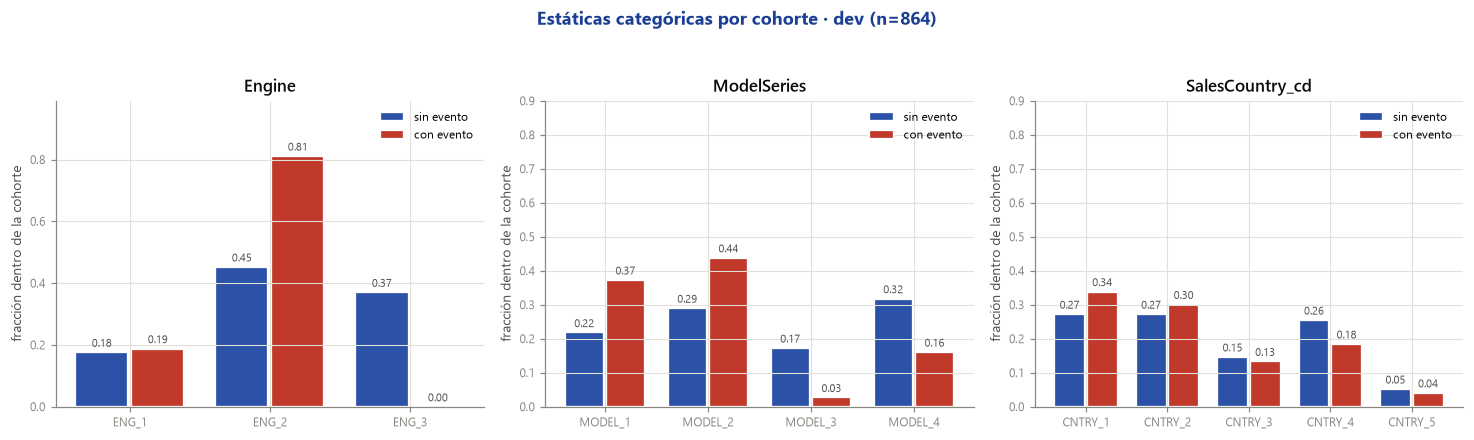

In [8]:
CATEGORICAS = ["static_Engine", "static_ModelSeries", "static_SalesCountry_cd"]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 3.8))
for ax, columna in zip(axes, CATEGORICAS):
    tabla = pd.crosstab(veh[columna], veh["event_observed"])
    frac = tabla / tabla.sum()
    x = np.arange(len(frac))
    ancho = 0.38
    for i, flag in enumerate(COHORT_ORDER):
        if flag not in frac.columns:
            continue
        barras = ax.bar(x + (i - 0.5) * (ancho + 0.02), frac[flag], ancho,
                        color=COHORT_COLORS[flag], label=COHORT_LABELS[flag],
                        edgecolor="white", linewidth=1.5)
        ax.bar_label(barras, fmt="%.2f", fontsize=7, color=INK["secondary"], padding=2)
    ax.set_xticks(x, frac.index, rotation=0)
    ax.set_title(columna.replace("static_", ""))
    ax.set_ylabel("fracción dentro de la cohorte")
    ax.set_ylim(0, max(0.9, frac.to_numpy().max() * 1.22))
    ax.legend(loc="upper right")
fig.suptitle("Estáticas categóricas por cohorte · dev (n=864)", y=1.04, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

In [9]:
# El sesgo de ENG_3 (docs/memoria/f1-sesgo-eng3.md), recontado dentro de dev.
motor = pd.crosstab(veh["static_Engine"], veh["event_observed"])
motor.columns = ["sanos", "con_evento"]
motor = motor.assign(
    frac_sanos=lambda d: d["sanos"] / d["sanos"].sum(),
    frac_con_evento=lambda d: d["con_evento"] / d["con_evento"].sum(),
    tasa_de_eventos=lambda d: d["con_evento"] / (d["sanos"] + d["con_evento"]),
)
print("ENG_3 en dev: %d vehículos sanos, %d con evento" %
      (int(motor.loc["ENG_3", "sanos"]), int(motor.loc["ENG_3", "con_evento"])))
print("(el doc reporta, sobre los 1081: 268 sanos y 0 con evento)\n")
motor.round(4)

ENG_3 en dev: 212 vehículos sanos, 0 con evento
(el doc reporta, sobre los 1081: 268 sanos y 0 con evento)



,sanos,con_evento,frac_sanos,frac_con_evento,tasa_de_eventos
static_Engine,,,,,
ENG_1,101,55,0.1766,0.1884,0.3526
ENG_2,259,237,0.4528,0.8116,0.4778
ENG_3,212,0,0.3706,0.0000,0.0000


**El sesgo se sostiene en dev, tal cual.** `ENG_3` son 212 vehículos sanos y
**cero** con evento: la regla `Engine == ENG_3 ⇒ sano` acierta el 100% de las veces
adentro de este dataset y ninguna afuera. Por eso `Engine` está en
`features.static_excluded` de `configs/data/panel_v1.yaml` y **no entra al
modelo**. Se muestra igual —es una figura del informe— pero con el cartel puesto.

`ModelSeries` y `SalesCountry_cd` no tienen ese problema: aparecen en las dos
cohortes con proporciones comparables.

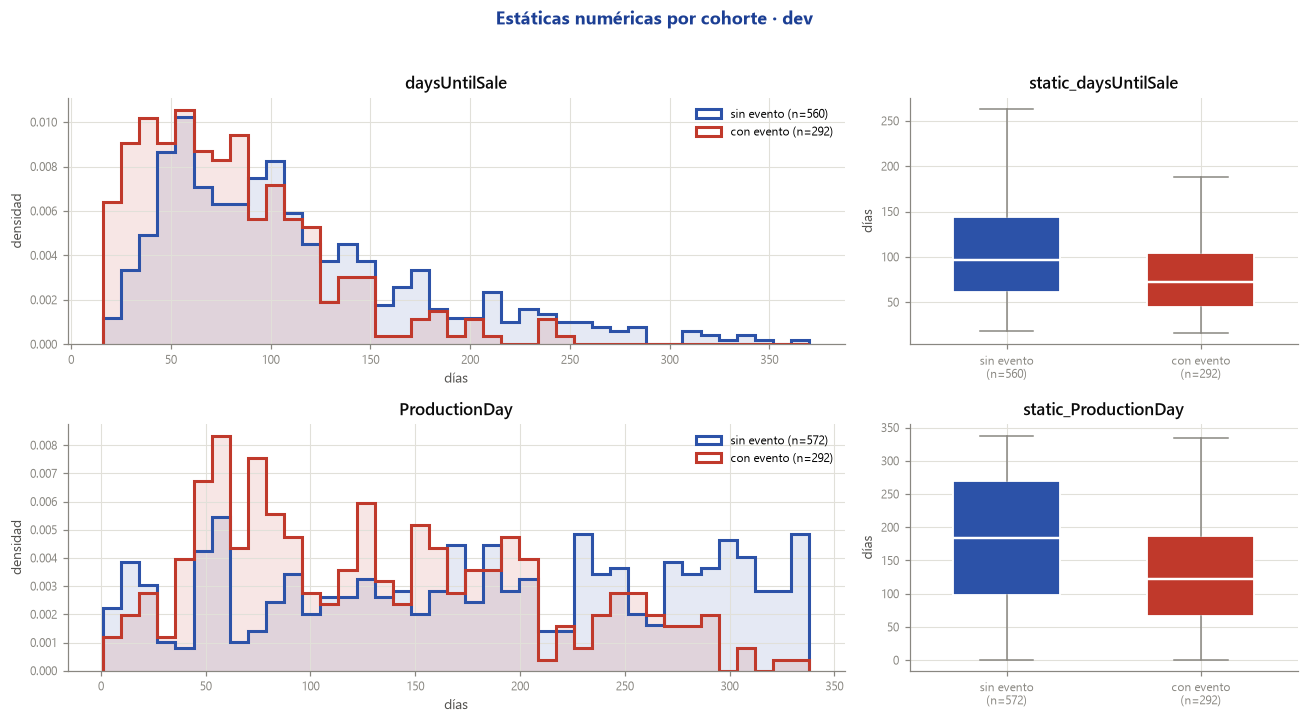

,variable,mediana_sanos,mediana_evento,ratio,prob_supera,p_mannwhitney
0,static_daysUntilSale,97.0,72.0,0.7423,0.3486,0.0
1,static_ProductionDay,184.5,122.0,0.6612,0.3555,0.0


In [10]:
NUMERICAS_ESTATICAS = ["static_daysUntilSale", "static_ProductionDay"]

fig, axes = plt.subplots(2, 2, figsize=(12, 6.4), gridspec_kw={"width_ratios": [2, 1]})
for fila, columna in enumerate(NUMERICAS_ESTATICAS):
    ax = axes[fila, 0]
    bins = np.linspace(veh[columna].min(), veh[columna].max(), 40)
    for flag in COHORT_ORDER:
        side = veh.loc[veh["event_observed"].eq(flag), columna].dropna()
        ax.hist(side, bins=bins, density=True, histtype="step", lw=2,
                color=COHORT_COLORS[flag], label=f"{COHORT_LABELS[flag]} (n={len(side)})")
        ax.hist(side, bins=bins, density=True, color=COHORT_COLORS[flag], alpha=0.12)
    ax.set_title(columna.replace("static_", ""))
    ax.set_xlabel("días")
    ax.set_ylabel("densidad")
    ax.legend(loc="upper right")
    cohort_box(axes[fila, 1], veh, columna, titulo="", ylabel="días")
fig.suptitle("Estáticas numéricas por cohorte · dev", y=1.02, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

compara_cohortes(veh, NUMERICAS_ESTATICAS).round(4)

**Atención con estas dos.** `daysUntilSale` y `ProductionDay` **sí** están en el
set base de `panel_v1.yaml` (`features.static_columns`), y las dos separan
cohortes: los vehículos con evento se produjeron y se vendieron **antes**. Eso no
es física del motor, es cómo se armó la muestra —a un vehículo producido tarde no
le dio tiempo de registrar un evento antes del corte de los datos—. §7.3 lo
cuantifica, y §3.3 muestra el caso extremo: para el 79% de los vehículos con
evento, `daysUntilSale` es **numéricamente igual** a la etiqueta.

## 3 · Etiqueta, anclaje temporal y censura

La etiqueta es la cohorte: `IdentificationDate` presente ⇔ evento registrado. Lo
que **no** viene dado es *dónde* cae ese evento sobre el eje de km, que es lo que
F2 necesita para armar `time_to_event_km` y la etiqueta por punto de corte.

F1 encontró el puente (`docs/memoria/f1-anclaje-temporal.md`):

```
fecha_evento = origen + ProductionDay + IdentificationDate
odo_evento   = interpolar esa fecha sobre los viajes del vehículo
```

Acá se re-estima el origen **sobre dev** y se mira qué sale al aplicarlo. La
estimación es exploratoria: el valor que F2 congele sale de su propio cómputo, no
de este notebook.

### 3.1 · Tasa de eventos y el anclaje, recalculados en dev

In [11]:
resumen_etiqueta = pd.DataFrame({
    "n_vehículos": [len(veh), int((veh["event_observed"] == 0).sum()), int(veh["event_observed"].sum())],
    "fracción": [1.0, (veh["event_observed"] == 0).mean(), veh["event_observed"].mean()],
}, index=["dev (total)", "sin evento (censurados)", "con evento"])
print(resumen_etiqueta.round(4).to_string())
print(f"\ntasa de eventos · dev {veh['event_observed'].mean():.4f} | "
      f"holdout declara dev {split['dev']['event_rate']:.4f} y test {split['test']['event_rate']:.4f}")
print("(el universo completo de 1081 da 0,3377 — el split estratificó por evento a propósito)")

                         n_vehículos  fracción
dev (total)                      864     1.000
sin evento (censurados)          572     0.662
con evento                       292     0.338

tasa de eventos · dev 0.3380 | holdout declara dev 0.3380 y test 0.3364
(el universo completo de 1081 da 0,3377 — el split estratificó por evento a propósito)


           primer_viaje − ProductionDay  … − daysUntilSale
std [d]                            0.76               61.8
IQR [d]                            0.00               72.0
rango [d]                         12.00              353.0

origen estimado sobre dev: día 20107 desde epoch = 2025-01-19
F1 reporta sobre los 1094: std 0,70 · IQR 0,00 · rango 12  ->  el puente se sostiene en dev.


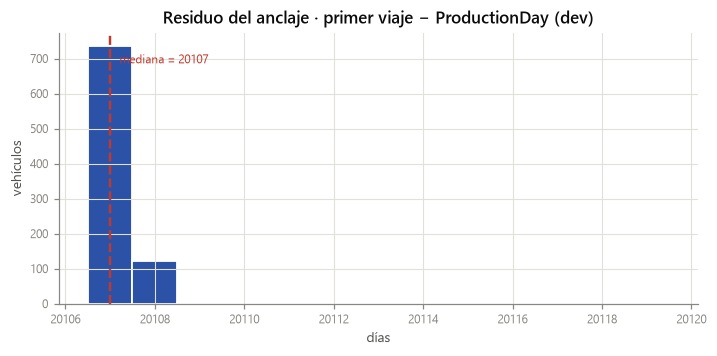

In [12]:
# El anclaje: `primer_viaje - ProductionDay` tiene que ser casi constante entre
# vehículos si `ProductionDay` está en el eje del calendario con origen común.
offset = veh["anchor_offset_days"].dropna()
alternativa = offset - veh.loc[offset.index, "static_daysUntilSale"]
anclaje = pd.DataFrame({
    "primer_viaje − ProductionDay": [offset.std(), offset.quantile(0.75) - offset.quantile(0.25),
                                     offset.max() - offset.min()],
    "… − daysUntilSale": [alternativa.std(), alternativa.quantile(0.75) - alternativa.quantile(0.25),
                          alternativa.max() - alternativa.min()],
}, index=["std [d]", "IQR [d]", "rango [d]"]).round(2)
print(anclaje.to_string())
print(f"\norigen estimado sobre dev: día {META['anchor_origin_day_since_epoch']:.0f} desde epoch "
      f"= {pd.Timestamp('1970-01-01') + pd.Timedelta(days=META['anchor_origin_day_since_epoch']):%Y-%m-%d}")
print("F1 reporta sobre los 1094: std 0,70 · IQR 0,00 · rango 12  ->  el puente se sostiene en dev.")

fig, ax = plt.subplots(figsize=(7.5, 3.2))
ax.hist(offset, bins=np.arange(offset.min() - 0.5, offset.max() + 1.5), color=BLUE,
        edgecolor="white", linewidth=1.2)
ax.axvline(offset.median(), color=ALERT_RED, lw=1.6, ls="--")
ax.annotate(f"mediana = {offset.median():.0f}", xy=(offset.median(), ax.get_ylim()[1] * 0.92),
            xytext=(6, 0), textcoords="offset points", color=ALERT_RED, fontsize=8, va="top")
ax.set_title("Residuo del anclaje · primer viaje − ProductionDay (dev)")
ax.set_xlabel("días")
ax.set_ylabel("vehículos")
plt.show()

**El anclaje se sostiene en dev**: IQR de **0 días** contra un rango de
`ProductionDay` de 337. La traducción del evento al eje de km está técnicamente
disponible. Lo que sigue es qué devuelve al aplicarla.

### 3.2 · La flota pasa sus primeros ~85 días sin moverse

Antes de proyectar el evento sobre el odómetro hace falta saber cómo crece el
odómetro. El perfil por día desde producción lo dice de una: hasta el día ~80 la
mediana de la flota no pasa de 20 km, y a partir de ahí despega. Es el vehículo en
el concesionario —`daysUntilSale` tiene mediana 86 días—.

Esto no es un detalle: significa que **cualquier fecha de evento temprana proyecta
a un odómetro cercano a cero aunque el anclaje sea perfecto.**

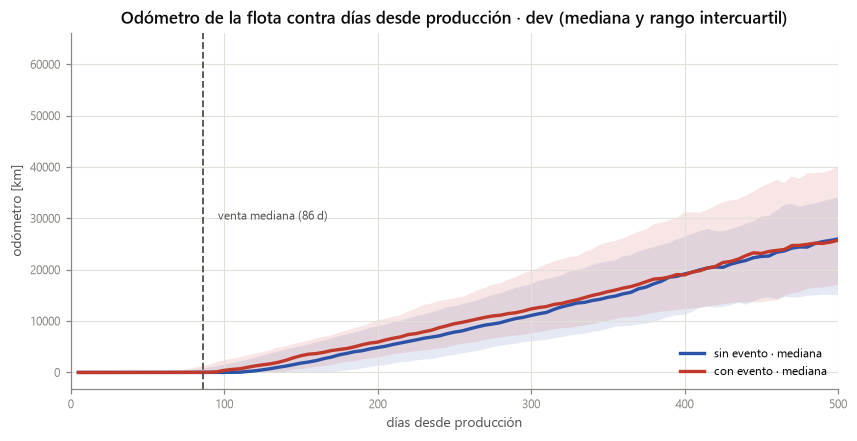

event_observed        sin evento  con evento
day_since_production                        
20                           5.0         4.0
40                           7.0         7.0
60                          10.0        11.0
80                          12.0        18.0
100                         20.0       407.0
120                        305.0      1262.0
160                       2309.0      3673.0
200                       4847.0      5908.0
300                      11102.0     12370.0


In [13]:
perfil = cache["odo_profile_dev"]
venta_mediana = veh["static_daysUntilSale"].median()

fig, ax = plt.subplots(figsize=(9, 4.2))
for flag in COHORT_ORDER:
    side = perfil[perfil["event_observed"].eq(flag)].sort_values("day_since_production")
    ax.plot(side["day_since_production"], side["median"], color=COHORT_COLORS[flag], lw=2.2,
            label=f"{COHORT_LABELS[flag]} · mediana")
    ax.fill_between(side["day_since_production"], side["p25"], side["p75"],
                    color=COHORT_COLORS[flag], alpha=0.12, lw=0)
ax.axvline(venta_mediana, color=INK["secondary"], lw=1.2, ls="--")
ax.annotate(f"venta mediana ({venta_mediana:.0f} d)", xy=(venta_mediana, ax.get_ylim()[1] * 0.45),
            xytext=(10, 0), textcoords="offset points", fontsize=8, color=INK["secondary"])
ax.set_title("Odómetro de la flota contra días desde producción · dev (mediana y rango intercuartil)")
ax.set_xlabel("días desde producción")
ax.set_ylabel("odómetro [km]")
ax.set_xlim(0, 500)
ax.legend(loc="lower right")
plt.show()

print(perfil[perfil["day_since_production"].isin([20, 40, 60, 80, 100, 120, 160, 200, 300])]
      .pivot(index="day_since_production", columns="event_observed", values="median")
      .rename(columns=COHORT_LABELS).round(0).to_string())

### 3.3 · `IdentificationDate` es igual a `daysUntilSale` en el 79% de los positivos

Al aplicar la fórmula del anclaje aparece algo que nadie documentó y que cambia el
alcance de F2.

vehículos con evento en dev                       : 292
  IdentificationDate == daysUntilSale (exacto)    : 231  (79.1%)
  IdentificationDate  > daysUntilSale             : 61
  IdentificationDate  < daysUntilSale             : 0

delta (días) en los que difieren: mediana 159, rango 1–268


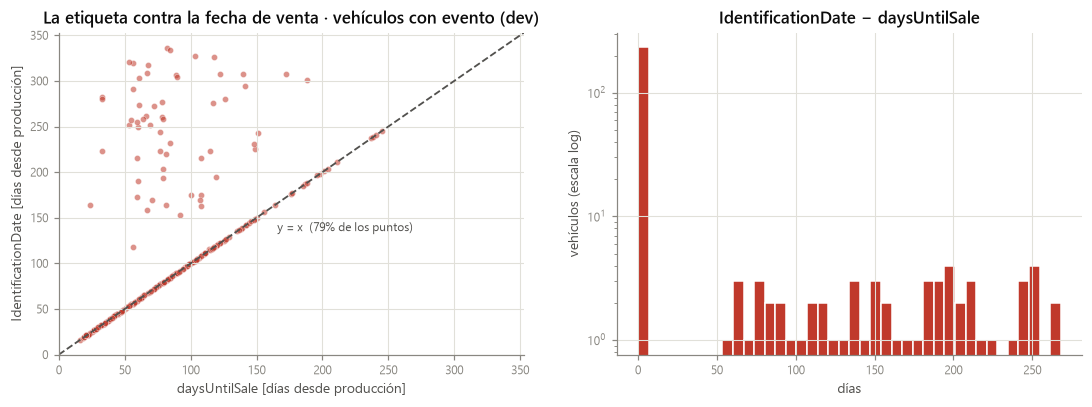

In [14]:
eventos = veh[veh["event_observed"].eq(1)].copy()
eventos["delta_ident_venta"] = eventos["event_day_since_production"] - eventos["static_daysUntilSale"]

iguales = int(eventos["ident_equals_sale"].sum())
print(f"vehículos con evento en dev                       : {len(eventos)}")
print(f"  IdentificationDate == daysUntilSale (exacto)    : {iguales}  ({iguales / len(eventos):.1%})")
print(f"  IdentificationDate  > daysUntilSale             : {int((eventos['delta_ident_venta'] > 0).sum())}")
print(f"  IdentificationDate  < daysUntilSale             : {int((eventos['delta_ident_venta'] < 0).sum())}")
print(f"\ndelta (días) en los que difieren: mediana {eventos.loc[eventos['delta_ident_venta'] > 0, 'delta_ident_venta'].median():.0f}, "
      f"rango {eventos.loc[eventos['delta_ident_venta'] > 0, 'delta_ident_venta'].min():.0f}–"
      f"{eventos.loc[eventos['delta_ident_venta'] > 0, 'delta_ident_venta'].max():.0f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
ax.scatter(eventos["static_daysUntilSale"], eventos["event_day_since_production"], s=16,
           color=ALERT_RED, alpha=0.55, edgecolor="white", linewidth=0.4)
lim = [0, max(eventos["static_daysUntilSale"].max(), eventos["event_day_since_production"].max()) * 1.05]
ax.plot(lim, lim, color=INK["secondary"], lw=1.2, ls="--")
ax.annotate("y = x  (79% de los puntos)", xy=(lim[1] * 0.45, lim[1] * 0.45), xytext=(6, -14),
            textcoords="offset points", fontsize=8, color=INK["secondary"])
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("daysUntilSale [días desde producción]")
ax.set_ylabel("IdentificationDate [días desde producción]")
ax.set_title("La etiqueta contra la fecha de venta · vehículos con evento (dev)")

ax = axes[1]
ax.hist(eventos["delta_ident_venta"], bins=40, color=ALERT_RED, edgecolor="white", linewidth=1.0)
ax.set_yscale("log")
ax.set_title("IdentificationDate − daysUntilSale")
ax.set_xlabel("días")
ax.set_ylabel("vehículos (escala log)")
plt.show()

Dos hechos, no interpretaciones:

- **En 231 de los 292 vehículos con evento de dev (79,1%), `IdentificationDate` es
  exactamente igual a `daysUntilSale`.**
- **En el 100% de los casos, `IdentificationDate >= daysUntilSale`.** Nunca hay un
  evento anterior a la venta.

Que dos columnas coincidan exactamente en 231 filas no es física: es cómo se pobló
el dato. Para ese 79%, la fecha del evento coincide con la fecha de venta, y con el
perfil de §3.2 eso la deja con el odómetro casi en cero.

### 3.4 · Qué pasa al proyectar el evento al eje de km

Dos lecturas posibles del eje de días, las dos calculadas en el cache:

- **A** — la literal del anexo 7.3: `IdentificationDate` son días desde
  **producción**. `fecha = origen + ProductionDay + IdentificationDate`.
- **B** — la alternativa: días desde la **venta**.
  `fecha = origen + ProductionDay + daysUntilSale + IdentificationDate`.

La columna que decide no es el odómetro sino **cuánto historial de viajes queda
antes del evento**: sin historial por delante no hay ventana W que agregar ni gap
G que blanquear, y la fila no se puede etiquetar.

                                        A · días desde producción  B · días desde la venta
odo mediano [km]                                             16.7                   3663.0
odo p25 [km]                                                  9.0                   1438.8
odo p75 [km]                                                526.6                   9484.6
% de viajes antes del evento (mediana)                        3.4                     25.4
vehículos con <5% del historial antes                       182.0                     41.0
vehículos con <2.000 km antes                               235.0                     86.0

(sobre 292 vehículos con evento de dev)


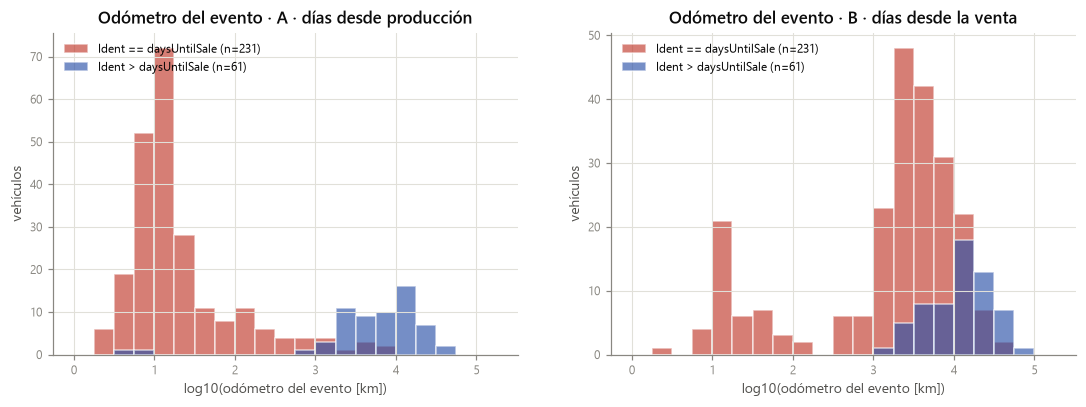

In [15]:
def resumen_hipotesis(frame, prefijo, etiqueta):
    odo = frame[f"{prefijo}_odo_km"]
    frac = frame[f"{prefijo}_frac_trips_before"]
    return pd.Series({
        "odo mediano [km]": odo.median(),
        "odo p25 [km]": odo.quantile(0.25),
        "odo p75 [km]": odo.quantile(0.75),
        "% de viajes antes del evento (mediana)": 100 * frac.median(),
        "vehículos con <5% del historial antes": int((frac < 0.05).sum()),
        "vehículos con <2.000 km antes": int((odo < 2000).sum()),
    }, name=etiqueta)


comparacion = pd.concat([
    resumen_hipotesis(eventos, "event", "A · días desde producción"),
    resumen_hipotesis(eventos, "event_alt", "B · días desde la venta"),
], axis=1)
print(comparacion.round(1).to_string())
print(f"\n(sobre {len(eventos)} vehículos con evento de dev)")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
for ax, (prefijo, titulo) in zip(axes, [("event", "A · días desde producción"),
                                        ("event_alt", "B · días desde la venta")]):
    for grupo, color, etiqueta in [
        (eventos[eventos["ident_equals_sale"]], ALERT_RED, "Ident == daysUntilSale (n=%d)" % iguales),
        (eventos[~eventos["ident_equals_sale"]], BLUE, "Ident > daysUntilSale (n=%d)" % (len(eventos) - iguales)),
    ]:
        ax.hist(np.log10(grupo[f"{prefijo}_odo_km"].clip(lower=1)), bins=np.arange(0, 5.4, 0.25),
                color=color, alpha=0.65, edgecolor="white", linewidth=1.0, label=etiqueta)
    ax.set_title(f"Odómetro del evento · {titulo}")
    ax.set_xlabel("log10(odómetro del evento [km])")
    ax.set_ylabel("vehículos")
    ax.legend(loc="upper left")
plt.show()

In [16]:
# Lo mismo, partido por el grupo que define el problema.
por_grupo = eventos.assign(grupo=np.where(eventos["ident_equals_sale"], "Ident == venta", "Ident > venta")) \
    .groupby("grupo")[["event_odo_km", "event_frac_trips_before", "event_alt_odo_km", "event_alt_frac_trips_before"]] \
    .median().round(3)
por_grupo.columns = ["A · odo [km]", "A · frac viajes antes", "B · odo [km]", "B · frac viajes antes"]
print(por_grupo.to_string())
print("\nDónde cae el evento respecto de la ventana de viajes observada (hipótesis A):")
print(eventos["event_source"].value_counts().to_string())

                A · odo [km]  A · frac viajes antes  B · odo [km]  B · frac viajes antes
grupo                                                                                   
Ident == venta        13.000                  0.023      2886.000                  0.196
Ident > venta       7388.212                  0.390     12810.655                  0.567

Dónde cae el evento respecto de la ventana de viajes observada (hipótesis A):
event_source
interpolado                  290
posterior_al_ultimo_viaje      2


**El resultado bajo la lectura literal es degenerado para el 79% de los
positivos.** Con la hipótesis A, esos 231 vehículos tienen el evento con una
mediana de **13 km** de odómetro y el **2,3%** de sus viajes por delante: no hay
historial para agregar una ventana ni para blanquear un gap. Los 61 restantes —los
que tienen `IdentificationDate > daysUntilSale`— dan una mediana de 7.388 km y
39% del historial, que sí es un evento utilizable.

La hipótesis B saca a todos de la zona degenerada (mediana 2.886 km y 20% del
historial para el grupo problemático), pero **no está respaldada por el anexo
7.3**, que dice "días desde producción" sin ambigüedad. Queda como **hipótesis
abierta**, no como decisión: elegirla porque los números quedan mejor es
exactamente la clase de decisión que el holdout existe para evitar.

Lo que sí queda establecido, y bloquea a F2:

> **Con `IdentificationDate` leído según el diccionario, la posición del evento
> sobre el eje de km es inutilizable para el 79% de los vehículos con evento de
> dev.** Antes de construir el panel hay que decidir qué se hace con esos 231
> vehículos: preguntarle a Ford, restringir las filas etiquetadas a los 61 con
> fecha discriminante, o pasar a un objetivo a nivel vehículo en vez de por corte.

Ninguna de esas tres salidas es de este notebook. Está en `docs/memoria/`.

### 3.5 · Supervivencia sobre el eje de odómetro (Kaplan-Meier)

Duración = odómetro del evento si el vehículo tiene evento, último odómetro
observado (`trip_odo_max`) si está censurado. **El lado censurado no depende del
anclaje**: `trip_odo_max` es dato directo. El lado de los eventos sí, así que la
curva se muestra con las dos hipótesis y con el caveat puesto.

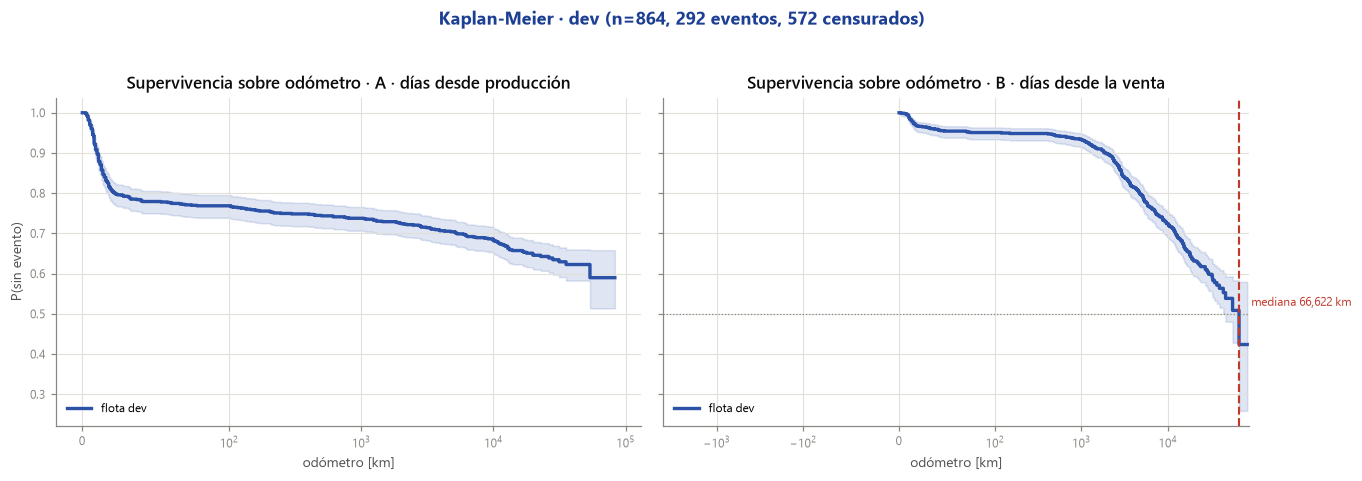

In [17]:
def km_fit(frame, duracion, evento, etiqueta):
    kmf = KaplanMeierFitter(label=etiqueta)
    kmf.fit(frame[duracion].clip(lower=1), frame[evento])
    return kmf


fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=True)
for ax, (columna, titulo) in zip(axes, [("duration_km", "A · días desde producción"),
                                        ("duration_km_alt", "B · días desde la venta")]):
    kmf = km_fit(veh, columna, "event_observed", "flota dev")
    kmf.plot_survival_function(ax=ax, color=BLUE, lw=2.2, ci_alpha=0.15)
    mediana = kmf.median_survival_time_
    if np.isfinite(mediana):
        ax.axhline(0.5, color=INK["muted"], lw=0.8, ls=":")
        ax.axvline(mediana, color=ALERT_RED, lw=1.4, ls="--")
        ax.annotate(f"mediana {mediana:,.0f} km", xy=(mediana, 0.52), xytext=(8, 0),
                    textcoords="offset points", fontsize=8, color=ALERT_RED)
    ax.set_title(f"Supervivencia sobre odómetro · {titulo}")
    ax.set_xlabel("odómetro [km]")
    ax.set_ylabel("P(sin evento)")
    ax.set_xscale("symlog", linthresh=100)
    ax.legend(loc="lower left")
fig.suptitle("Kaplan-Meier · dev (n=864, 292 eventos, 572 censurados)", y=1.03,
             color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

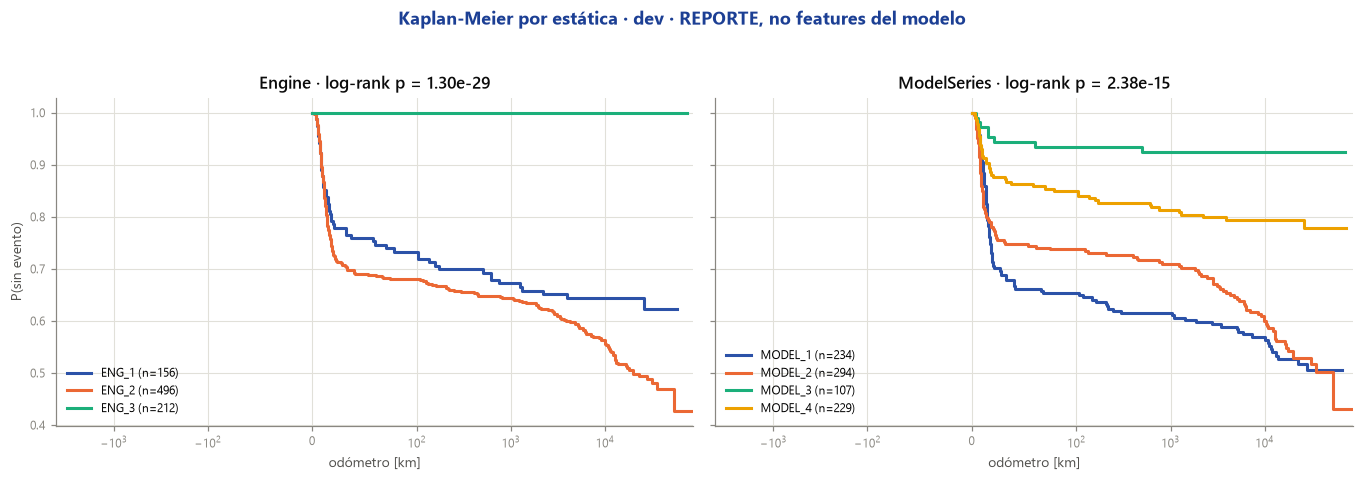

La curva plana de ENG_3 es el sesgo de muestreo de §2, no un motor mejor:
con 0 eventos en 212 vehículos, la curva no puede bajar. Por eso `Engine` no entra al modelo.


In [18]:
# Por motor y por modelo. REPORTE, no modelado: `Engine` está excluido del set base.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2), sharey=True)
for ax, columna in zip(axes, ["static_Engine", "static_ModelSeries"]):
    for i, (nivel, grupo) in enumerate(veh.groupby(columna, observed=True)):
        if len(grupo) < 20:
            continue
        kmf = km_fit(grupo, "duration_km", "event_observed", f"{nivel} (n={len(grupo)})")
        kmf.plot_survival_function(ax=ax, color=CATEGORICAL[i % len(CATEGORICAL)], lw=2, ci_show=False)
    prueba = multivariate_logrank_test(veh["duration_km"].clip(lower=1), veh[columna],
                                       veh["event_observed"])
    ax.set_title(f"{columna.replace('static_', '')} · log-rank p = {prueba.p_value:.2e}")
    ax.set_xlabel("odómetro [km]")
    ax.set_ylabel("P(sin evento)")
    ax.set_xscale("symlog", linthresh=100)
    ax.legend(loc="lower left", ncol=1)
fig.suptitle("Kaplan-Meier por estática · dev · REPORTE, no features del modelo", y=1.03,
             color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

print("La curva plana de ENG_3 es el sesgo de muestreo de §2, no un motor mejor:")
print("con 0 eventos en 212 vehículos, la curva no puede bajar. Por eso `Engine` no entra al modelo.")

## 4 · Calidad del eje de odómetro

El odómetro es el eje por defecto del contrato (regla 4), así que sus defectos son
los defectos del panel. `docs/memoria/f1-calidad-odometro.md` los midió sobre el
universo completo; acá se recuentan sobre dev y se compara.

In [19]:
nulos_odo = veh["signal_odo_null"] / veh["n_signals"]
calidad = pd.DataFrame([
    {"problema": "`OdometerValue` nulo en `signals` (global)",
     "dev": veh["signal_odo_null"].sum() / veh["n_signals"].sum(),
     "documentado (1081)": 0.1115, "unidad": "fracción de filas"},
    {"problema": "`OdometerValue` nulo · mediana POR VEHÍCULO",
     "dev": nulos_odo.median(), "documentado (1081)": np.nan, "unidad": "fracción de filas"},
    {"problema": "`KilometerPerHour` nulo en `trips`",
     "dev": (veh["speed_null_frac"] * veh["n_trips"]).sum() / veh["n_trips"].sum(),
     "documentado (1081)": 0.3247, "unidad": "fracción de filas"},
    {"problema": "vehículos con algún viaje de km negativo",
     "dev": int((veh["n_km_negative"] > 0).sum()), "documentado (1081)": 24, "unidad": "vehículos"},
    {"problema": "viajes con km negativo",
     "dev": int(veh["n_km_negative"].sum()), "documentado (1081)": 165, "unidad": "viajes"},
])
print(calidad.to_string(index=False))

                                   problema        dev  documentado (1081)            unidad
 `OdometerValue` nulo en `signals` (global)   0.047128              0.1115 fracción de filas
`OdometerValue` nulo · mediana POR VEHÍCULO   0.000000                 NaN fracción de filas
         `KilometerPerHour` nulo en `trips`   0.319982              0.3247 fracción de filas
   vehículos con algún viaje de km negativo  24.000000             24.0000         vehículos
                     viajes con km negativo 165.000000            165.0000            viajes


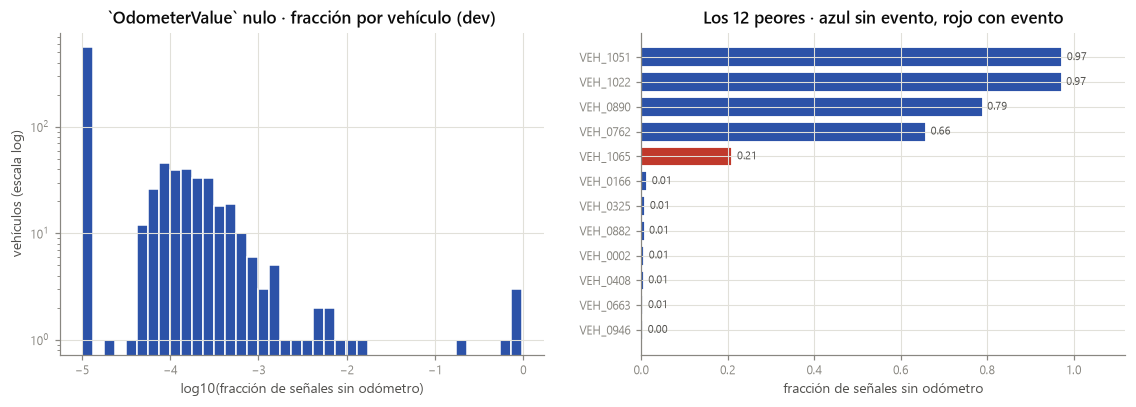

vehículos con >50% de sus señales sin odómetro : 4
vehículos con  <1% de sus señales sin odómetro : 858 de 864
mediana por vehículo                           : 0.00000


In [20]:
# El hallazgo: el 11% de nulos no está repartido, está concentrado en un puñado de vehículos.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax = axes[0]
ax.hist(np.log10(nulos_odo.clip(lower=1e-5)), bins=40, color=BLUE, edgecolor="white", linewidth=1.0)
ax.set_yscale("log")
ax.set_title("`OdometerValue` nulo · fracción por vehículo (dev)")
ax.set_xlabel("log10(fracción de señales sin odómetro)")
ax.set_ylabel("vehículos (escala log)")

ax = axes[1]
peores = veh.assign(frac_nulo=nulos_odo).nlargest(12, "frac_nulo")
colores = [COHORT_COLORS[int(f)] for f in peores["event_observed"]]
barras = ax.barh(peores["vehicle_id"], peores["frac_nulo"], color=colores, edgecolor="white", linewidth=1.2)
ax.bar_label(barras, fmt="%.2f", fontsize=7, color=INK["secondary"], padding=3)
ax.invert_yaxis()
ax.set_xlim(0, 1.12)
ax.set_title("Los 12 peores · azul sin evento, rojo con evento")
ax.set_xlabel("fracción de señales sin odómetro")
plt.show()

print(f"vehículos con >50% de sus señales sin odómetro : {int((nulos_odo > 0.5).sum())}")
print(f"vehículos con  <1% de sus señales sin odómetro : {int((nulos_odo < 0.01).sum())} de {len(veh)}")
print(f"mediana por vehículo                           : {nulos_odo.median():.5f}")

**Esto corrige la lectura de `f1-calidad-odometro.md`.** El doc dice "el 11% de
señales sin odómetro no se puede tirar sin pensar: si el nulo correlaciona con el
tipo de mensaje, descartarlas sesga las features de severidad". La estructura real
es distinta y más manejable: **el nulo correlaciona con el vehículo, no con el
mensaje.** La mediana por vehículo es 0,00%, 858 de los 864 están por debajo del 1%,
y cuatro vehículos concentran el problema con entre el 66% y el 97% de sus señales
sin odómetro.

Consecuencia práctica para F2: descartar las filas sin odómetro no sesga a la
flota —858 de los 864 pierden menos del 1% de sus filas— pero **deja sin ninguna
feature de `signals` a los 4 vehículos que tienen más de la mitad de sus señales
sin odómetro** (hasta el 97%). Son los que necesitan la imputación por el viaje que
contiene al `eventTimestamp`; el resto no.

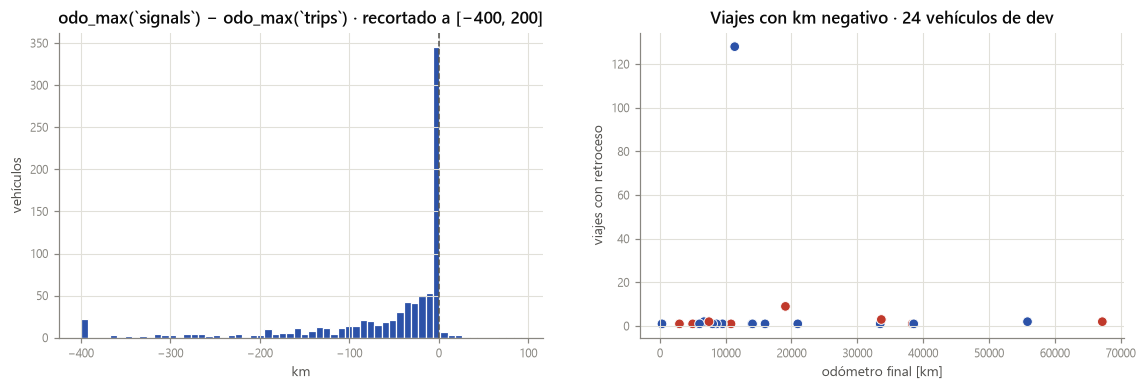

count     864.0
mean      -85.8
std       405.3
min     -7821.0
5%       -278.4
25%       -78.0
50%       -17.5
75%         0.0
95%         0.0
max        92.0

Documentado sobre los 1081: mediana −18 km, p25 −77 km, mínimo −7821 km.
`trips` manda como eje y `signals` se alinea contra él (f1-calidad-odometro.md).


In [21]:
# Desfase entre los dos odómetros y retrocesos.
desfase = (veh["signal_odo_max"] - veh["trip_odo_max"]).dropna()
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.6))
ax = axes[0]
ax.hist(desfase.clip(-400, 200), bins=60, color=BLUE, edgecolor="white", linewidth=0.8)
ax.axvline(0, color=INK["secondary"], lw=1.0, ls="--")
ax.set_title("odo_max(`signals`) − odo_max(`trips`) · recortado a [−400, 200]")
ax.set_xlabel("km")
ax.set_ylabel("vehículos")

ax = axes[1]
retroceso = veh[veh["n_km_negative"] > 0]
ax.scatter(retroceso["trip_odo_max"], retroceso["n_km_negative"],
           c=[COHORT_COLORS[int(f)] for f in retroceso["event_observed"]], s=40,
           edgecolor="white", linewidth=0.6)
ax.set_title(f"Viajes con km negativo · {len(retroceso)} vehículos de dev")
ax.set_xlabel("odómetro final [km]")
ax.set_ylabel("viajes con retroceso")
plt.show()

print(desfase.describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1).to_string())
print("\nDocumentado sobre los 1081: mediana −18 km, p25 −77 km, mínimo −7821 km.")
print("`trips` manda como eje y `signals` se alinea contra él (f1-calidad-odometro.md).")

## 5 · Uso y contexto (`trips`)

1.947.866 viajes de dev, ya deduplicados. Dos grabados distintos:

- **distribuciones a nivel viaje** (histogramas y cuantiles **exactos** sobre los
  1,9M, no una muestra);
- **boxplots a nivel vehículo**, donde cada punto es un vehículo. Son los que
  importan para F2: las features del panel van a ser agregados por vehículo y
  ventana, así que la pregunta es cuánto se separan los **vehículos**, no los
  viajes.

### 5.1 · Distribuciones a nivel viaje

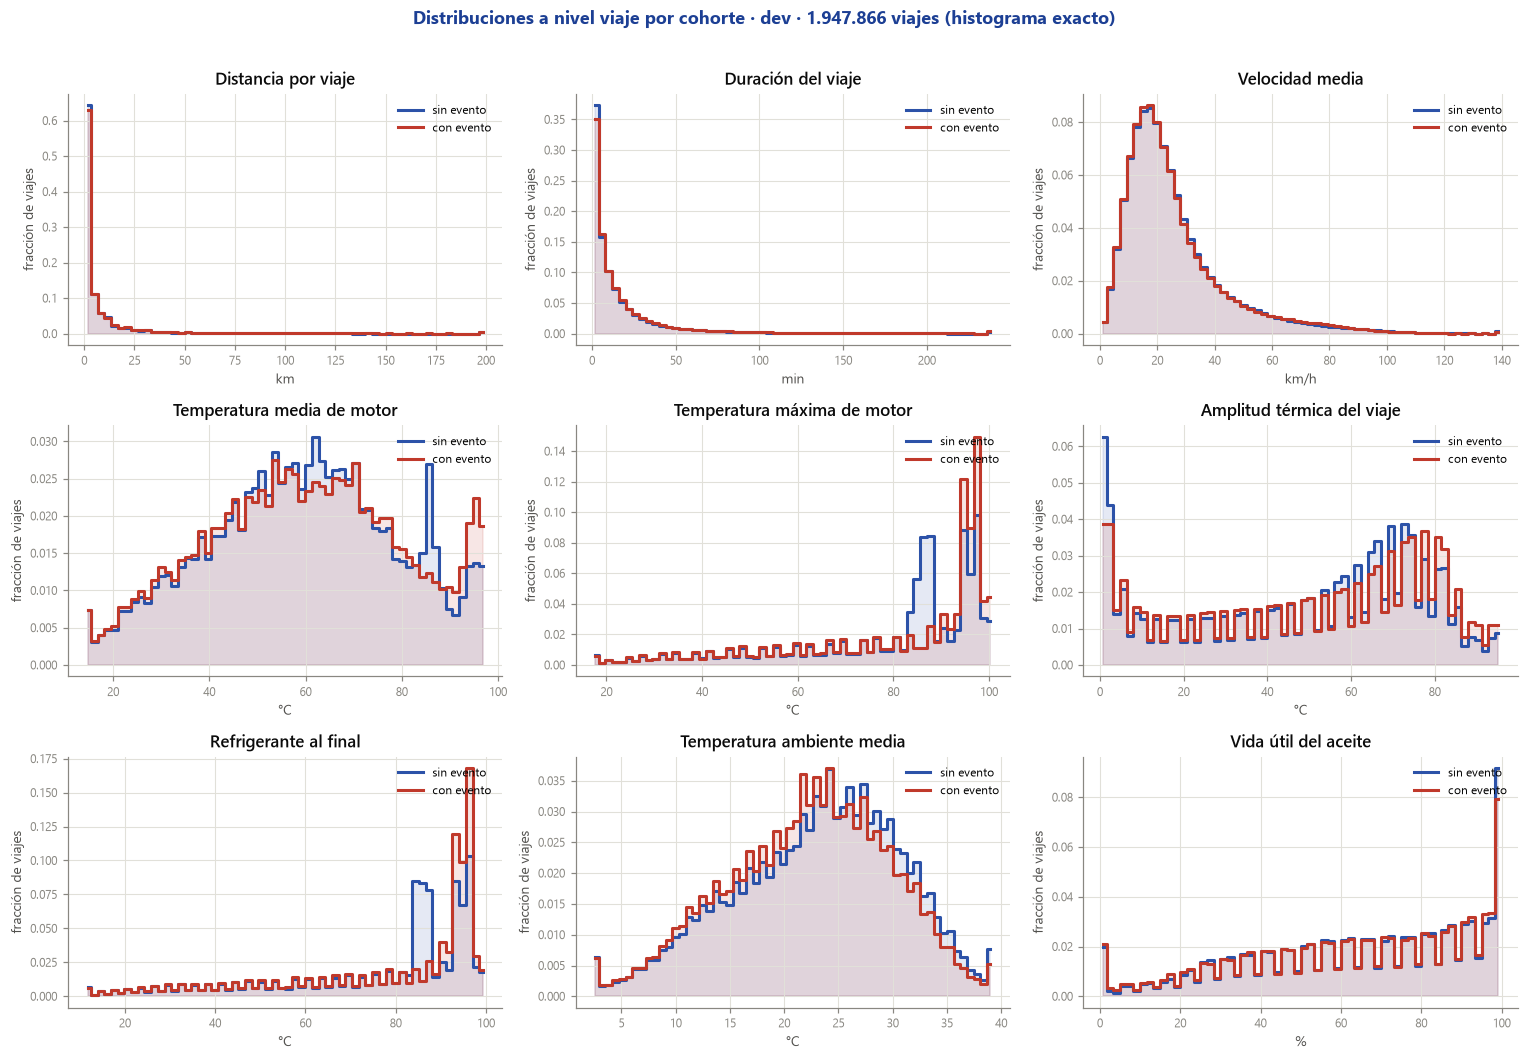

In [22]:
hist = cache["trip_hist_dev"]
PANEL_VIAJE = [
    ("trip_km", "Distancia por viaje", "km"),
    ("trip_duration_min", "Duración del viaje", "min"),
    ("KilometerPerHour", "Velocidad media", "km/h"),
    ("EngineTemperatureAvg", "Temperatura media de motor", "°C"),
    ("EngineTemperatureMax", "Temperatura máxima de motor", "°C"),
    ("engine_temp_amplitude", "Amplitud térmica del viaje", "°C"),
    ("CoolantTemperatureEnd", "Refrigerante al final", "°C"),
    ("AirTemperatureAvg", "Temperatura ambiente media", "°C"),
    ("EngineOilLifePCStart", "Vida útil del aceite", "%"),
]
fig, axes = plt.subplots(3, 3, figsize=(14, 9.5))
for ax, (metrica, titulo, unidad) in zip(axes.ravel(), PANEL_VIAJE):
    cohort_hist(ax, hist, metrica, titulo=titulo, xlabel=unidad)
fig.suptitle("Distribuciones a nivel viaje por cohorte · dev · 1.947.866 viajes (histograma exacto)",
             y=1.01, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

In [23]:
# Cuantiles exactos, que es lo que un histograma no deja leer con precisión.
cuant = cache["trip_quantiles_dev"]
tabla = cuant[cuant["q"].isin([0.05, 0.25, 0.5, 0.75, 0.95])].pivot_table(
    index="metric", columns=["event_observed", "q"], values="value")
tabla.columns = [f"{COHORT_LABELS[a]} · p{int(b * 100)}" for a, b in tabla.columns]
tabla.loc[[m for m, _, _ in PANEL_VIAJE]].round(2)

,sin evento · p5,sin evento · p25,sin evento · p50,sin evento · p75,sin evento · p95,con evento · p5,con evento · p25,con evento · p50,con evento · p75,con evento · p95
metric,,,,,,,,,,
trip_km,0.00,0.00,2.00,6.00,41.00,0.00,0.00,2.00,7.00,45.00
trip_duration_min,0.02,1.90,7.03,19.25,68.83,0.00,2.22,7.57,20.50,76.90
KilometerPerHour,6.83,14.06,21.10,31.86,63.21,6.69,13.93,20.86,31.65,64.51
EngineTemperatureAvg,25.67,45.50,59.67,73.25,91.67,25.33,44.67,59.50,74.33,94.00
EngineTemperatureMax,34.00,70.00,86.00,95.00,99.00,34.00,68.00,92.00,96.00,99.00
engine_temp_amplitude,1.00,23.00,55.00,72.00,85.00,2.00,25.00,56.00,75.00,88.00
CoolantTemperatureEnd,29.00,66.00,86.00,94.00,97.00,28.00,64.00,90.00,95.00,97.00
AirTemperatureAvg,9.38,17.75,23.78,28.69,34.50,9.21,17.00,22.75,27.67,33.75
EngineOilLifePCStart,16.00,44.00,68.00,88.00,100.00,13.00,43.00,67.00,88.00,100.00


### 5.2 · Agregados por vehículo: dónde se separan las cohortes

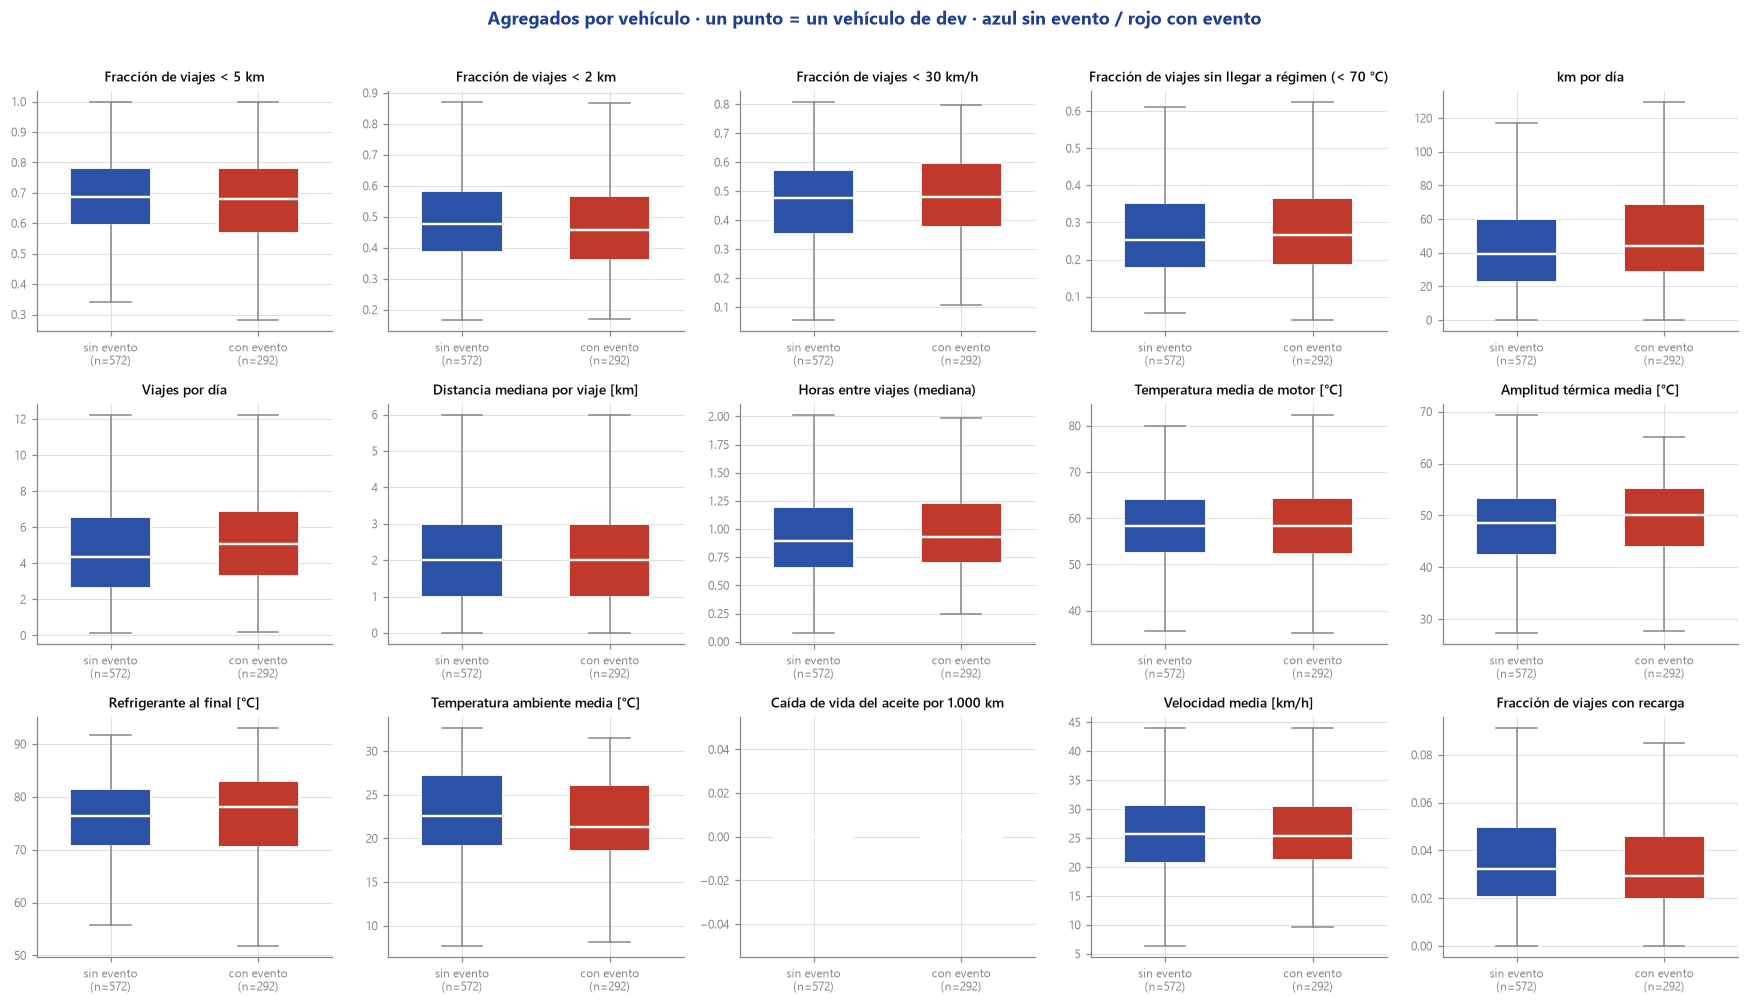

In [24]:
USO_POR_VEHICULO = [
    ("short_trip_frac", "Fracción de viajes < 5 km"),
    ("very_short_trip_frac", "Fracción de viajes < 2 km"),
    ("urban_trip_frac", "Fracción de viajes < 30 km/h"),
    ("below_regime_frac", "Fracción de viajes sin llegar a régimen (< 70 °C)"),
    ("km_per_day", "km por día"),
    ("trips_per_day", "Viajes por día"),
    ("trip_km_median", "Distancia mediana por viaje [km]"),
    ("hours_between_trips_median", "Horas entre viajes (mediana)"),
    ("engine_temp_avg_median", "Temperatura media de motor [°C]"),
    ("engine_temp_amplitude_mean", "Amplitud térmica media [°C]"),
    ("coolant_end_mean", "Refrigerante al final [°C]"),
    ("air_temp_avg_mean", "Temperatura ambiente media [°C]"),
    ("oil_life_drop_per_1000km", "Caída de vida del aceite por 1.000 km"),
    ("speed_mean", "Velocidad media [km/h]"),
    ("refuel_frac", "Fracción de viajes con recarga"),
]
fig, axes = plt.subplots(3, 5, figsize=(16, 9))
for ax, (columna, titulo) in zip(axes.ravel(), USO_POR_VEHICULO):
    cohort_box(ax, veh, columna, titulo=titulo)
    ax.set_title(titulo, fontsize=9)
fig.suptitle("Agregados por vehículo · un punto = un vehículo de dev · azul sin evento / rojo con evento",
             y=1.01, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

In [25]:
comparacion_uso = compara_cohortes(veh, [c for c, _ in USO_POR_VEHICULO])
print("`prob_supera` = P(un vehículo con evento > uno sano). 0,5 = sin diferencia.")
comparacion_uso.round(4)

`prob_supera` = P(un vehículo con evento > uno sano). 0,5 = sin diferencia.


,variable,mediana_sanos,mediana_evento,ratio,prob_supera,p_mannwhitney
4,km_per_day,39.3010,43.8719,1.1163,0.5602,0.0038
5,trips_per_day,4.3742,5.0876,1.1631,0.5595,0.0042
9,engine_temp_amplitude_mean,48.4428,50.0560,1.0333,0.5561,0.0069
11,air_temp_avg_mean,22.6202,21.2761,0.9406,0.4462,0.0096
1,very_short_trip_frac,0.4754,0.4576,0.9627,0.4549,0.0300
10,coolant_end_mean,76.3636,78.0705,1.0224,0.5428,0.0396
2,urban_trip_frac,0.4762,0.4811,1.0102,0.5377,0.0693
6,trip_km_median,2.0000,2.0000,1.0000,0.5370,0.0687
7,hours_between_trips_median,0.8962,0.9321,1.0400,0.5356,0.0862
3,below_regime_frac,0.2515,0.2675,1.0637,0.5270,0.1933


**Lectura.** Las familias A (térmica / trayectos cortos) y C (uso) separan poco: la
probabilidad de superación se queda entre 0,45 y 0,56 en todas. El
`below_regime_frac` —la traducción más directa de la hipótesis causal del
enunciado— apenas se mueve.

Eso no las descarta: acá se está comparando el **historial completo** de cada
vehículo, que no es lo que va a ver el modelo. F2 las mide sobre una ventana W
móvil, donde un vehículo puede tener meses de uso urbano intenso y después
normalizar. Lo que esta tabla sí dice es que **no hay que esperar que el uso
resuelva el problema por sí solo**: la señal fuerte está en §6.

### 5.3 · Rangos imposibles y la trampa de `EngineOilLifePC`

Antes de convertir nada en feature conviene mirar los extremos. Hay dos cosas
distintas acá: valores fuera de rango físico (que se recortan) y una columna que
está completa, varía, y aun así no sirve para la feature que el plan §4 le asignó.

In [26]:
muestra_viajes = check_dev_only(cache["trips_sample_dev"], "trips_sample_dev")

RANGOS_ESPERADOS = {
    "KilometerPerHour": (0, 200, "km/h"),
    "FuelLvlStartPc": (0, 100, "%"),
    "FuelLvlEndPc": (0, 100, "%"),
    "AirTemperatureAvg": (-30, 55, "°C"),
    "CoolantTemperatureStart": (-40, 130, "°C"),
    "EngineTemperatureMax": (-40, 130, "°C"),
    "trip_km": (0, 2000, "km"),
    "trip_duration_min": (0, 1440, "min"),
}
filas = []
for columna, (bajo, alto, unidad) in RANGOS_ESPERADOS.items():
    serie = muestra_viajes[columna].dropna()
    filas.append({
        "columna": columna, "unidad": unidad,
        "min": serie.min(), "p01": serie.quantile(0.01), "p99": serie.quantile(0.99),
        "max": serie.max(),
        "rango esperado": f"[{bajo}, {alto}]",
        "frac fuera de rango": float(((serie < bajo) | (serie > alto)).mean()),
    })
rangos = pd.DataFrame(filas)
print("Sobre la muestra de 250.000 viajes de dev (los cuantiles del cache son exactos;")
print("esta tabla mira colas, que es donde la muestra alcanza):")
rangos.round(4)

  [ok] trips_sample_dev           250000 filas ·  864 vehículos · 0 de test
Sobre la muestra de 250.000 viajes de dev (los cuantiles del cache son exactos;
esta tabla mira colas, que es donde la muestra alcanza):


,columna,unidad,min,p01,p99,max,rango esperado,frac fuera de rango
0,KilometerPerHour,km/h,0.0024,3.3155,91.3111,135600.0000,"[0, 200]",0.0003
1,FuelLvlStartPc,%,-5.2174,0.5435,102.8264,103.4786,"[0, 100]",0.1046
2,FuelLvlEndPc,%,-5.2174,0.4348,102.8264,103.4786,"[0, 100]",0.0996
3,AirTemperatureAvg,°C,-73.0000,4.1875,37.9500,79.1250,"[-30, 55]",0.0003
4,CoolantTemperatureStart,°C,-60.0000,2.0000,97.0000,109.0000,"[-40, 130]",0.0000
5,EngineTemperatureMax,°C,-4.0000,21.0000,101.0000,113.0000,"[-40, 130]",0.0000
6,trip_km,km,-230.0000,0.0000,134.0000,777.0000,"[0, 2000]",0.0001
7,trip_duration_min,min,0.0000,0.0000,159.1012,29124.6667,"[0, 1440]",0.0001


viajes de la muestra con el dato               : 249,400 de 250,000
`EngineOilLifePCStart` == `EngineOilLifePCEnd` : 1.0000
delta intra-viaje distinto de cero             : 0 viajes

El NIVEL sí varía: min 0, mediana 68, max 100 (101 valores distintos)


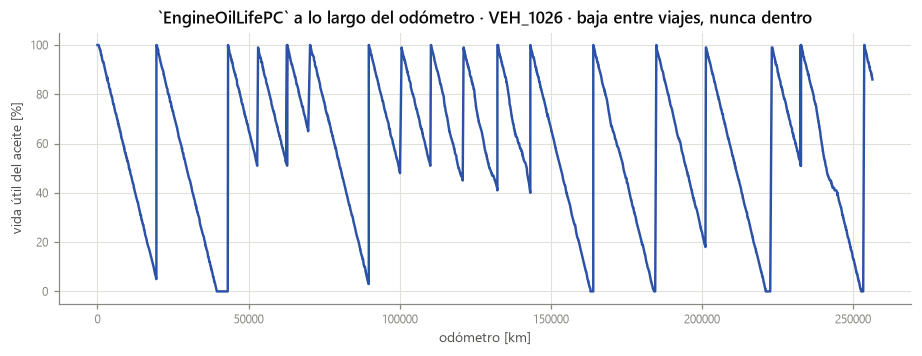

In [27]:
# La trampa: `EngineOilLifePC` está completa y varía... pero nunca DENTRO de un viaje.
# (el dropna() importa: NaN != 0 da True y contaría los nulos como deltas reales)
con_dato = muestra_viajes[["EngineOilLifePCStart", "EngineOilLifePCEnd", "oil_life_drop"]].dropna()
iguales_en_viaje = con_dato["EngineOilLifePCStart"].eq(con_dato["EngineOilLifePCEnd"])
print(f"viajes de la muestra con el dato               : {len(con_dato):,} de {len(muestra_viajes):,}")
print(f"`EngineOilLifePCStart` == `EngineOilLifePCEnd` : {iguales_en_viaje.mean():.4f}")
print(f"delta intra-viaje distinto de cero             : {int(con_dato['oil_life_drop'].ne(0).sum())} viajes")
print(f"\nEl NIVEL sí varía: min {muestra_viajes['EngineOilLifePCStart'].min():.0f}, "
      f"mediana {muestra_viajes['EngineOilLifePCStart'].median():.0f}, "
      f"max {muestra_viajes['EngineOilLifePCStart'].max():.0f} "
      f"({muestra_viajes['EngineOilLifePCStart'].nunique()} valores distintos)")

vehiculo = muestra_viajes["vehicle_id"].value_counts().index[0]
serie = muestra_viajes[muestra_viajes["vehicle_id"].eq(vehiculo)].sort_values("OdometerTripEnd")
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.plot(serie["OdometerTripEnd"], serie["EngineOilLifePCStart"], color=BLUE, lw=1.6)
ax.set_title(f"`EngineOilLifePC` a lo largo del odómetro · {vehiculo} · baja entre viajes, nunca dentro")
ax.set_xlabel("odómetro [km]")
ax.set_ylabel("vida útil del aceite [%]")
plt.show()

**Dos consecuencias para F2.**

1. **Recortar antes de agregar.** `KilometerPerHour` llega a **135.600 km/h**,
   `AirTemperatureAvg` baja a **−73 °C** y `trip_duration_min` sube a 20 días. Son
   colas finitas (menos del 0,05% de los viajes cada una), pero una media sin
   recorte las arrastra. `f1-calidad-odometro.md` ya sugiere recalcular la
   velocidad desde odómetro y tiempo; acá está el número que lo justifica.
   Caso aparte: **`FuelLvl*Pc` supera 100 en el 10% de los viajes** (hasta 103,5) y
   baja a −5,2. No es una cola: es que la escala no es un porcentaje literal, así
   que conviene tratarla como índice relativo y no recortarla a [0, 100] sin pensar.
2. **`feat_oil_life_drop_per_1000km` está mal especificada.**
   `EngineOilLifePCStart == EngineOilLifePCEnd` en el **100%** de los viajes: el
   delta intra-viaje es exactamente cero, siempre. La columna no está vacía —el
   nivel recorre 0–100 y baja a lo largo de la vida del vehículo— pero el índice se
   actualiza **entre** viajes, no dentro. La feature hay que redefinirla como
   **pendiente del nivel contra odómetro dentro de la ventana**, no como suma de
   caídas por viaje.

## 6 · Severidad y postratamiento

Acá está la señal. Tres vías, más una cuarta que nadie había mirado.

### 6.1 · `Message`: tasas por 1.000 km, **por vehículo**

`scripts/eda_raw.py` calculó estas tasas agregando toda la cohorte
(`docs/memoria/f1-senal-postratamiento.md`). Eso da un número por nivel y por
cohorte, y esconde la dispersión: un solo vehículo con 300.000 señales mueve el
promedio de los 864. Acá se calcula **una tasa por vehículo** y se mira la
distribución.

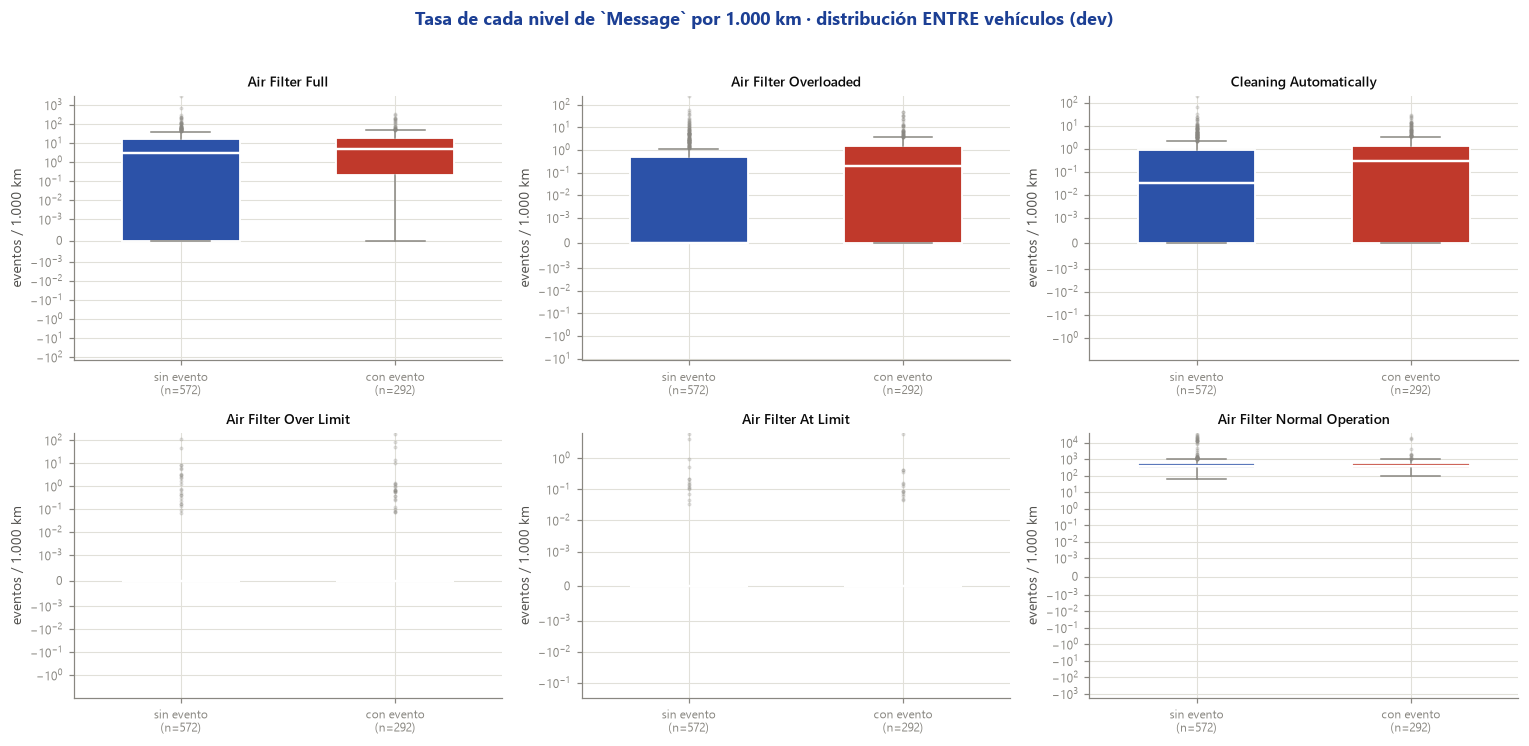

In [28]:
NIVELES = [("msg_full_per_1000km", "Air Filter Full"),
           ("msg_overloaded_per_1000km", "Air Filter Overloaded"),
           ("msg_cleaning_auto_per_1000km", "Cleaning Automatically"),
           ("msg_over_limit_per_1000km", "Air Filter Over Limit"),
           ("msg_at_limit_per_1000km", "Air Filter At Limit"),
           ("msg_normal_per_1000km", "Air Filter Normal Operation")]

fig, axes = plt.subplots(2, 3, figsize=(14, 6.6))
for ax, (columna, titulo) in zip(axes.ravel(), NIVELES):
    cohort_box(ax, veh, columna, titulo=titulo, ylabel="eventos / 1.000 km", logy=True, showfliers=True)
    ax.set_title(titulo, fontsize=9)
fig.suptitle("Tasa de cada nivel de `Message` por 1.000 km · distribución ENTRE vehículos (dev)",
             y=1.02, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

In [29]:
tasas = compara_cohortes(veh, [c for c, _ in NIVELES])
print("Mediana POR VEHÍCULO (no el agregado de la cohorte):")
print(tasas.round(4).to_string(index=False))

print("\nCuántos vehículos ven cada nivel alguna vez:")
conteos = cache["message_counts_dev"]
conteos = conteos[conteos["scope"].eq("full")].merge(veh[["vehicle_id", "event_observed"]], on="vehicle_id")
vistos = conteos.groupby(["Message", "event_observed"])["vehicle_id"].nunique().unstack(fill_value=0)
vistos.columns = [COHORT_LABELS[c] for c in vistos.columns]
vistos["frac sanos"] = vistos["sin evento"] / int((veh["event_observed"] == 0).sum())
vistos["frac con evento"] = vistos["con evento"] / int(veh["event_observed"].sum())
vistos.sort_values("con evento", ascending=False).round(3)

Mediana POR VEHÍCULO (no el agregado de la cohorte):
                    variable  mediana_sanos  mediana_evento  ratio  prob_supera  p_mannwhitney
   msg_overloaded_per_1000km         0.0000          0.2032    NaN       0.5934         0.0000
msg_cleaning_auto_per_1000km         0.0314          0.2886 9.2021       0.5710         0.0003
         msg_full_per_1000km         2.9717          5.2357 1.7618       0.5488         0.0177
   msg_over_limit_per_1000km         0.0000          0.0000    NaN       0.5224         0.0082
       msg_normal_per_1000km       409.1128        410.0056 1.0022       0.4817         0.3773
     msg_at_limit_per_1000km         0.0000          0.0000    NaN       0.5107         0.0974

Cuántos vehículos ven cada nivel alguna vez:


,sin evento,con evento,frac sanos,frac con evento
Message,,,,
Air Filter Normal Operation,572,292,1.000,1.000
Air Filter Full,408,231,0.713,0.791
Cleaning Automatically Air Filter,290,182,0.507,0.623
Air Filter Overloaded,224,167,0.392,0.572
Air Filter Over Limit,25,26,0.044,0.089
Air Filter At Limit,15,14,0.026,0.048
Stopped Cleaning Automatically Air Filter,17,12,0.030,0.041
Stopped Cleanning Manually Air Filter,20,11,0.035,0.038
Cleanning Manually Air Filter,3,1,0.005,0.003


**Los niveles "malos" aparecen en las dos cohortes**, que es el perfil de una
feature honesta y no de una etiqueta disfrazada (`f1-senal-postratamiento.md`). Lo
que agrega la vista por vehículo es la dispersión: la mediana de
`Air Filter Overloaded` es **0** en los sanos —solo lo ve el 39% de ellos, contra
el 57% de los que tienen evento—, así que la tasa agregada de la cohorte estaba
dominada por los vehículos que sí lo ven. Para F2 eso importa: una feature
que es cero en la mediana necesita tratarse como conteo raro (o acumularse sobre
ventanas largas), no como una tasa continua.

### 6.2 · `Acumulation` y el ciclo de regeneración

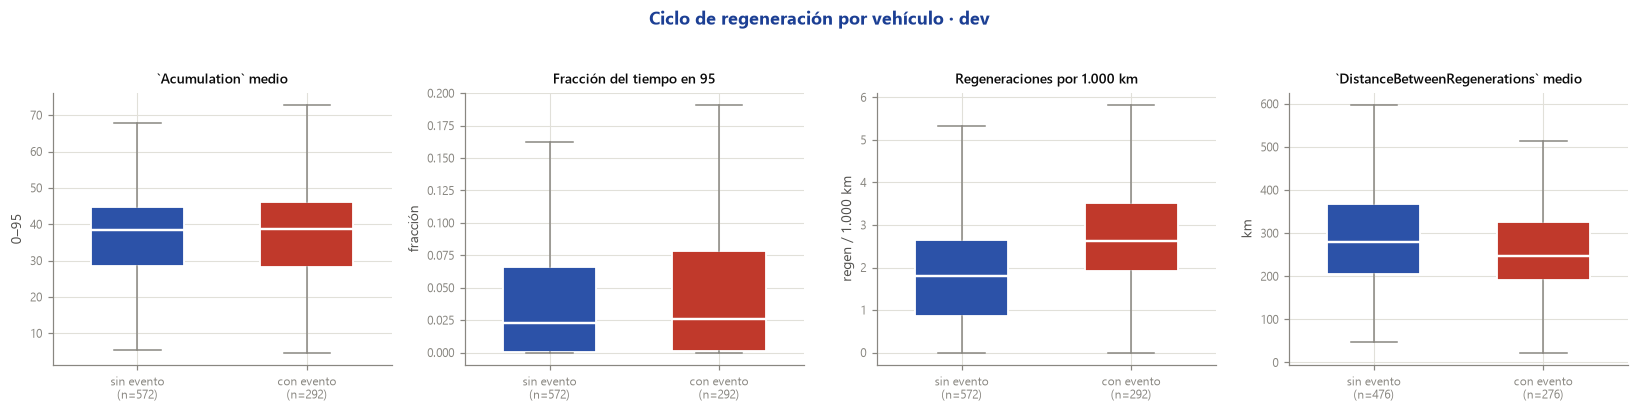

,variable,mediana_sanos,mediana_evento,ratio,prob_supera,p_mannwhitney
5,regen_per_1000km,1.7967,2.6132,1.4544,0.6857,0.0000
6,n_regenerations,31.0000,53.0000,1.7097,0.6539,0.0000
8,dist_between_regen_median,267.0000,226.2500,0.8474,0.4088,0.0000
2,acumulation_max,95.0000,95.0000,1.0000,0.4138,0.0000
9,acumulation_slope_per_1000km,0.6886,0.3873,0.5625,0.4167,0.0001
7,dist_between_regen_mean,279.3114,246.1152,0.8811,0.4295,0.0013
4,acumulation_saturated_frac,0.0225,0.0259,1.1520,0.5316,0.1255
0,acumulation_mean,38.4096,38.6721,1.0068,0.5240,0.2483
1,acumulation_median,35.0000,40.0000,1.1429,0.5239,0.2468
3,acumulation_high_frac,0.3908,0.3951,1.0111,0.5144,0.4871


In [30]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6))
for ax, (columna, titulo, unidad) in zip(axes, [
    ("acumulation_mean", "`Acumulation` medio", "0–95"),
    ("acumulation_saturated_frac", "Fracción del tiempo en 95", "fracción"),
    ("regen_per_1000km", "Regeneraciones por 1.000 km", "regen / 1.000 km"),
    ("dist_between_regen_mean", "`DistanceBetweenRegenerations` medio", "km"),
]):
    cohort_box(ax, veh, columna, titulo=titulo, ylabel=unidad)
    ax.set_title(titulo, fontsize=9)
fig.suptitle("Ciclo de regeneración por vehículo · dev", y=1.03, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

compara_cohortes(veh, ["acumulation_mean", "acumulation_median", "acumulation_max",
                       "acumulation_high_frac", "acumulation_saturated_frac",
                       "regen_per_1000km", "n_regenerations", "dist_between_regen_mean",
                       "dist_between_regen_median", "acumulation_slope_per_1000km"]).round(4)

**`regen_per_1000km` es la variable que más separa de todo el EDA**: mediana 2,61
en los que tienen evento contra 1,80 en los sanos, con `prob_supera` = 0,686. Es el
respaldo empírico de la familia B del plan §4 —regenerar más seguido por kilómetro
es el síntoma de trayectos que no completan el ciclo— y coincide con lo que F1
midió sobre los 1081 (2,63 vs 1,79).

`Acumulation` como **máximo** satura: llega a 95 en la mayoría de los vehículos de
las dos cohortes, así que sirve más como fracción de tiempo en niveles altos
dentro de una ventana que como máximo histórico.

### 6.3 · `DistanceBetweenRegenerations`: la tendencia, no el nivel

El plan §4 apuesta a la **tendencia** de esta variable ("probablemente la señal más
fuerte del dataset"). Sobre el historial completo el nivel medio separa poco; la
pendiente contra odómetro sí se mueve.

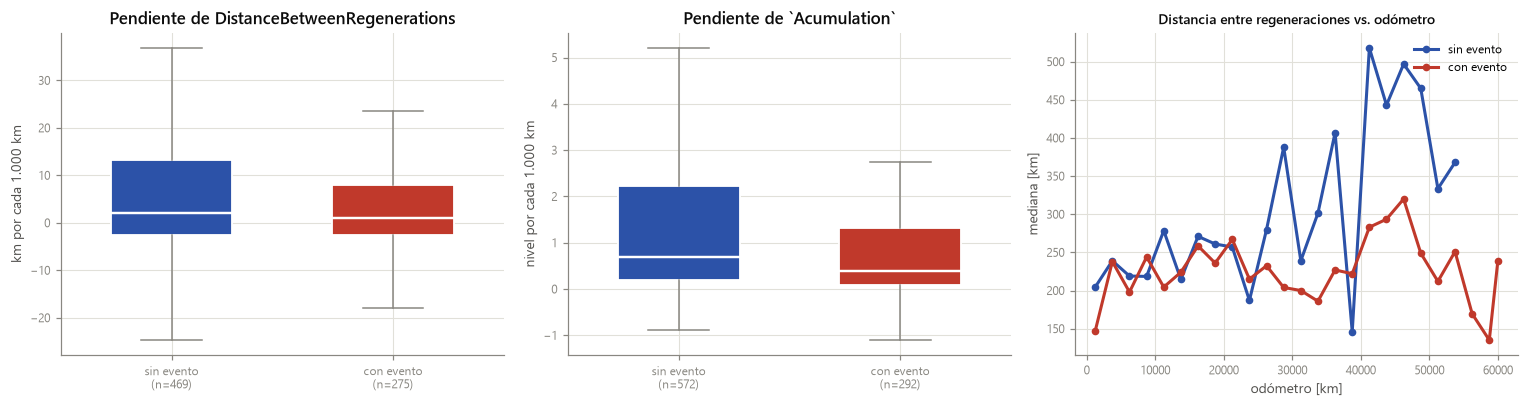

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
cohort_box(axes[0], veh, "dist_between_regen_slope_per_1000km",
           titulo="Pendiente de DistanceBetweenRegenerations", ylabel="km por cada 1.000 km")
cohort_box(axes[1], veh, "acumulation_slope_per_1000km",
           titulo="Pendiente de `Acumulation`", ylabel="nivel por cada 1.000 km")

ax = axes[2]
muestra = cache["signals_sample_dev"].merge(veh[["vehicle_id", "event_observed"]], on="vehicle_id")
muestra = muestra.dropna(subset=["OdometerValue", "DistanceBetweenRegenerations"])
for flag in COHORT_ORDER:
    side = muestra[muestra["event_observed"].eq(flag)]
    bins = np.linspace(0, 60000, 25)
    idx = np.digitize(side["OdometerValue"], bins)
    perfil = side.groupby(idx)["DistanceBetweenRegenerations"].median()
    centros = [(bins[min(i, len(bins) - 1)] + bins[max(i - 1, 0)]) / 2 for i in perfil.index]
    ax.plot(centros, perfil.to_numpy(), color=COHORT_COLORS[flag], lw=2, marker="o", ms=4,
            label=COHORT_LABELS[flag])
ax.set_title("Distancia entre regeneraciones vs. odómetro", fontsize=9)
ax.set_xlabel("odómetro [km]")
ax.set_ylabel("mediana [km]")
ax.legend(loc="upper right")
fig.tight_layout()
plt.show()

### 6.4 · `AirFilterStart/End` y `AirRegenerationStart/End`: qué son en realidad

Son las cuatro columnas que §1 encontró en el CSV y no en el diccionario oficial.
Nadie en `docs/memoria/` las analizó y `scripts/eda_raw.py` no las toca. Tres
pruebas.

In [32]:
# Prueba 1 · ¿comparten vocabulario `AirFilter*` y `signals.Message`?
niveles_filtro = set(cache["airfilter_counts_dev"]["level"].unique())
niveles_mensaje = set(cache["message_counts_dev"]["Message"].unique())
print(f"niveles de `AirFilterStart/End` : {len(niveles_filtro)}")
print(f"niveles de `signals.Message`    : {len(niveles_mensaje)}")
print(f"solo en AirFilter               : {sorted(niveles_filtro - niveles_mensaje) or 'ninguno'}")
print(f"solo en Message                 : {sorted(niveles_mensaje - niveles_filtro) or 'ninguno'}")
print("\nvocabulario compartido (incluye la misma errata 'Cleanning Manually'):")
for nivel in sorted(niveles_filtro):
    print("  ·", nivel)

niveles de `AirFilterStart/End` : 9
niveles de `signals.Message`    : 9
solo en AirFilter               : ninguno
solo en Message                 : ninguno

vocabulario compartido (incluye la misma errata 'Cleanning Manually'):
  · Air Filter At Limit
  · Air Filter Full
  · Air Filter Normal Operation
  · Air Filter Over Limit
  · Air Filter Overloaded
  · Cleaning Automatically Air Filter
  · Cleanning Manually Air Filter
  · Stopped Cleaning Automatically Air Filter
  · Stopped Cleanning Manually Air Filter


  [ok] alineación trips↔signals    16324 filas ·    8 vehículos · 0 de test

pares alineados                          : 16,324
`AirRegenerationEnd` == `Acumulation`    : 0.9980
correlación de Pearson                   : 0.9995
`AirFilterEnd` == `Message`              : 0.9998


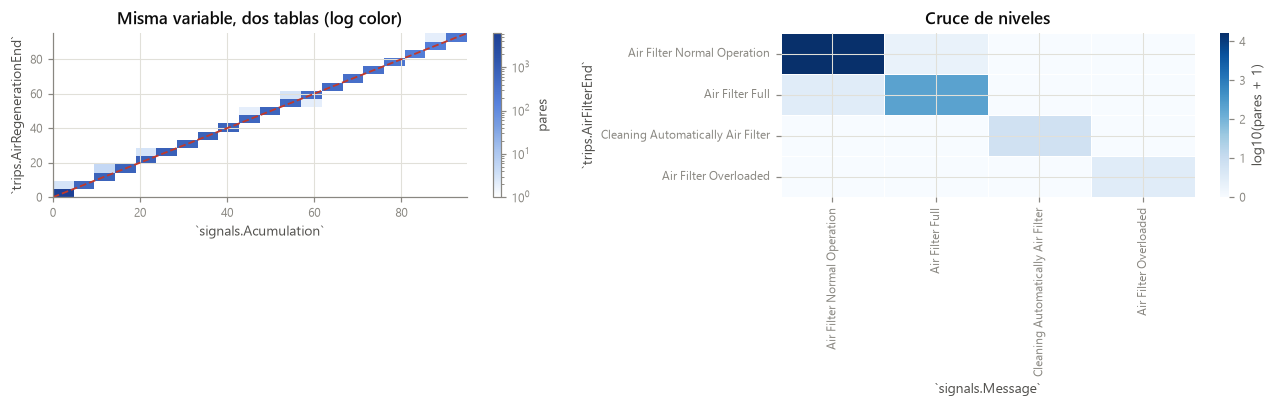

In [33]:
# Prueba 2 · ¿coinciden fila a fila? Se alinea el fin de cada viaje con la señal más
# cercana dentro de 30 minutos, sobre los vehículos sonda (historial completo en cache).
viajes_sonda = (cache["probe_trips_dev"][["vehicle_id", "TripDatetimeEnd", "AirRegenerationEnd", "AirFilterEnd"]]
                .dropna(subset=["TripDatetimeEnd"]).sort_values("TripDatetimeEnd"))
senales_sonda = (cache["probe_signals_dev"][["vehicle_id", "eventTimestamp", "Acumulation", "Message"]]
                 .dropna(subset=["eventTimestamp"]).sort_values("eventTimestamp"))
alineado = pd.merge_asof(viajes_sonda, senales_sonda, left_on="TripDatetimeEnd",
                         right_on="eventTimestamp", by="vehicle_id", direction="nearest",
                         tolerance=pd.Timedelta("30min")).dropna(subset=["Acumulation"])
check_dev_only(alineado, "alineación trips↔signals")

print(f"\npares alineados                          : {len(alineado):,}")
print(f"`AirRegenerationEnd` == `Acumulation`    : {(alineado['AirRegenerationEnd'] == alineado['Acumulation']).mean():.4f}")
print(f"correlación de Pearson                   : {alineado['AirRegenerationEnd'].corr(alineado['Acumulation']):.4f}")
print(f"`AirFilterEnd` == `Message`              : {(alineado['AirFilterEnd'] == alineado['Message']).mean():.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
ax = axes[0]
h = ax.hist2d(alineado["Acumulation"], alineado["AirRegenerationEnd"], bins=20,
              cmap=mpl.colors.LinearSegmentedColormap.from_list("ford", ["#ffffff", *SEQUENTIAL]),
              norm=mpl.colors.LogNorm())
ax.plot([0, 95], [0, 95], color=ALERT_RED, lw=1.2, ls="--")
ax.set_xlabel("`signals.Acumulation`")
ax.set_ylabel("`trips.AirRegenerationEnd`")
ax.set_title("Misma variable, dos tablas (log color)")
plt.colorbar(h[3], ax=ax, label="pares")

ax = axes[1]
niveles_orden = (alineado["Message"].value_counts().index.tolist())
tabla_cruz = pd.crosstab(alineado["AirFilterEnd"], alineado["Message"]).reindex(
    index=niveles_orden, columns=niveles_orden).fillna(0)
sns.heatmap(np.log10(tabla_cruz + 1), ax=ax, cmap="Blues", cbar_kws={"label": "log10(pares + 1)"},
            linewidths=0.6, linecolor="white")
ax.set_xlabel("`signals.Message`")
ax.set_ylabel("`trips.AirFilterEnd`")
ax.set_title("Cruce de niveles")
fig.tight_layout()
plt.show()

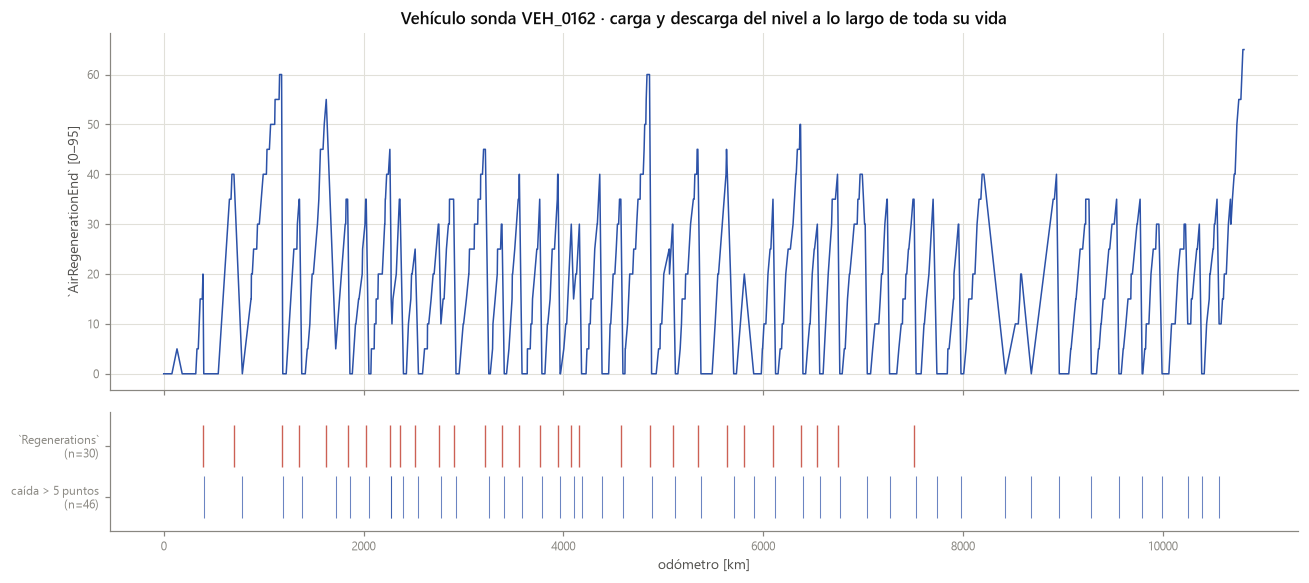

caídas de más de 5 puntos por 1.000 km (mediana en dev): 3.70
regeneraciones registradas en `signals` por 1.000 km (mediana): 2.10
correlación entre las dos (Spearman): 0.6862

vehículos de dev con más caídas que regeneraciones registradas: 781 de 864


In [34]:
# Prueba 3 · ¿se comporta como saturación de hollín? Tiene que subir con el uso y
# caer de golpe cuando hay regeneración. Historial COMPLETO del vehículo sonda.
sonda = META["probe_vehicles"][0]
tr = cache["probe_trips_dev"]
tr = tr[tr["vehicle_id"].eq(sonda)].sort_values("OdometerTripEnd")
sg = cache["probe_signals_dev"]
sg = sg[sg["vehicle_id"].eq(sonda) & sg["Regenerations"]]

fig, (ax, ax2) = plt.subplots(2, 1, figsize=(12, 5.4), sharex=True,
                              gridspec_kw={"height_ratios": [3, 1]})
ax.plot(tr["OdometerTripEnd"], tr["AirRegenerationEnd"], color=BLUE, lw=1.0)
ax.set_title(f"Vehículo sonda {sonda} · carga y descarga del nivel a lo largo de toda su vida")
ax.set_ylabel("`AirRegenerationEnd` [0–95]")

caidas = tr.loc[tr["air_regen_delta"] < -5, "OdometerTripEnd"]
ax2.vlines(caidas, 0, 1, color=BLUE, lw=0.7, alpha=0.7)
ax2.vlines(sg["OdometerValue"].dropna(), 1.2, 2.2, color=ALERT_RED, lw=0.9, alpha=0.8)
ax2.set_yticks([0.5, 1.7], [f"caída > 5 puntos\n(n={len(caidas)})",
                            f"`Regenerations`\n(n={int(sg['OdometerValue'].notna().sum())})"])
ax2.set_ylim(-0.3, 2.5)
ax2.grid(False)
ax2.set_xlabel("odómetro [km]")
fig.tight_layout()
plt.show()

print(f"caídas de más de 5 puntos por 1.000 km (mediana en dev): "
      f"{veh['air_regen_drops_per_1000km'].median():.2f}")
print(f"regeneraciones registradas en `signals` por 1.000 km (mediana): "
      f"{veh['regen_per_1000km'].median():.2f}")
print(f"correlación entre las dos (Spearman): "
      f"{spearmanr(veh['air_regen_drops_per_1000km'], veh['regen_per_1000km'], nan_policy='omit').statistic:.4f}")
print(f"\nvehículos de dev con más caídas que regeneraciones registradas: "
      f"{int((veh['air_regen_drops_per_1000km'] > veh['regen_per_1000km']).sum())} de {len(veh)}")

**Veredicto.**

*Hecho, medido:* `trips.AirRegenerationStart/End` y `signals.Acumulation` son **la
misma variable en dos tablas**: alineando cada fin de viaje con la señal más
cercana dentro de 30 minutos, coinciden **exactamente en el 99,8%** de 16.324
pares (Pearson 0,9995). `AirFilterStart/End` y `signals.Message` comparten el
vocabulario **completo** —los mismos 9 niveles, incluida la errata
"Cleanning Manually"— y coinciden en el 99,98% de los mismos pares. Es decir:
`trips` trae una foto al inicio y al final de cada viaje de las dos variables
dinámicas que `signals` trae por mensaje.

*Inferencia, bien respaldada pero no confirmada por Ford:* esas son las columnas
que el anexo 7.1 llama `DieselParticulateFilterStart/End` ("nivel de saturación /
carga de hollín del DPF [%]"). Los indicios: ocupan exactamente esa posición
faltante en `trips`; el anexo 7.2 describe `Acumulation` como "acumulación en el
filtro de aire [%]", que es el mismo concepto con el nombre anonimizado; el PDF
avisa en §4.2 que las variables vienen renombradas; y la serie se comporta como
saturación de hollín —sube con el uso, se descarga de golpe en cada regeneración—.

*Un detalle que sale de la última figura y que conviene tener presente:* el marcador
`signals.Regenerations` **está incompleto**. En el vehículo sonda hay 30 filas
marcadas y ninguna por encima de los ~7.500 km, mientras el nivel sigue
descargándose hasta el final de sus 10.800 km (46 caídas contra 30 marcas). En el agregado de dev pasa lo mismo: las
caídas de más de 5 puntos dan 3,70 por 1.000 km contra 2,10 regeneraciones
registradas. Como contador de ciclos, `AirRegeneration*` ve más que `Regenerations`
— otro motivo para preferir `trips` como fuente de la familia B.

*Lo que queda abierto:* no hay confirmación de Ford de la equivalencia de nombres,
y la escala llega a 95 en vez de 100, lo que sugiere un tope de reporte y no un
porcentaje literal. **Que sea el DPF es la hipótesis que mejor explica los datos,
no un hecho verificado.** Que sea la misma variable que `Acumulation`, sí lo es.

**Lo que esto desbloquea:** la familia B del plan §4 —pendiente del DPF contra
odómetro, nivel medio y máximo, fracción de viajes con delta positivo— **se puede
construir**, a nivel viaje, desde `trips.AirRegenerationStart/End`. El
`docs/memoria/f1-datos-reales.md` dice "no hay columna de DPF": hay dos, con otro
nombre y en las dos tablas.

## 7 · Correlaciones

**Caveat de la regla 6, que vale para toda esta sección.** Todos los agregados de
acá se calculan sobre el **historial completo** del vehículo, y se correlacionan
con `event_observed`, que es una etiqueta **a nivel vehículo** (la cohorte de la
que salió). Eso no es la tarea del modelo: el modelo predice si el evento cae en
`[corte+G, corte+G+H]` mirando solo una ventana hacia atrás.

Dos consecuencias concretas:

1. Cualquier variable de postratamiento (`Acumulation`, `Message`, regeneraciones,
   `AirRegeneration*`) que aparezca correlacionada acá **está midiendo la vida
   entera del vehículo, sin gap de blanking**. Un ρ alto en esta tabla no es un
   PR-AUC alto: es una señal de por dónde va a intentar memorizar el modelo si F2
   no pone el gap.
2. Las variables de **cobertura** (`n_trips`, `span_days`, `trip_odo_max`) no son
   features: son cuánto se observó a cada vehículo. Su correlación con la etiqueta
   es sesgo de muestreo, no física.

### 7.1 · Matriz de correlaciones entre agregados

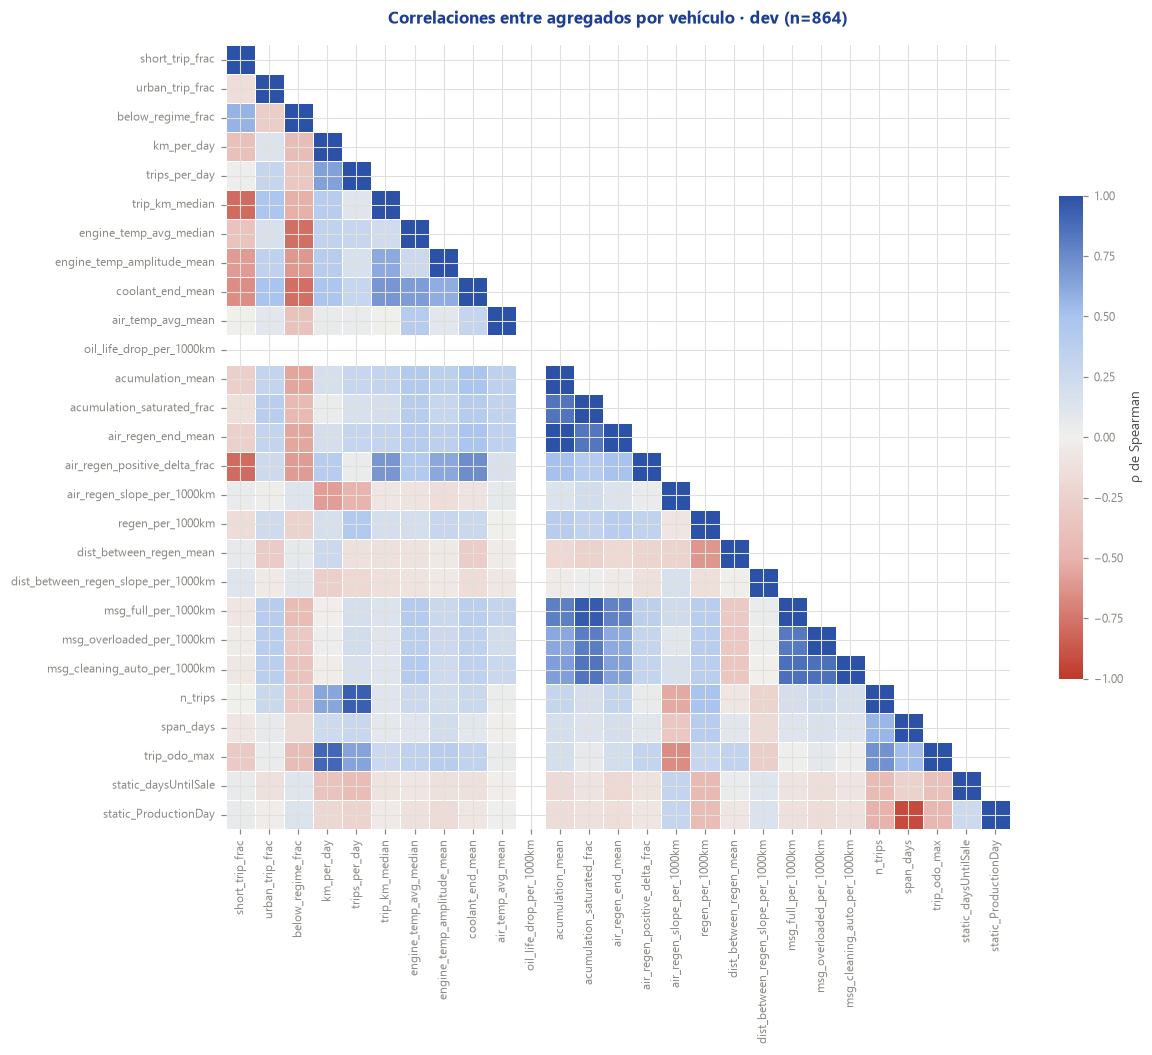

In [35]:
MATRIZ = [
    # uso y térmica
    "short_trip_frac", "urban_trip_frac", "below_regime_frac", "km_per_day", "trips_per_day",
    "trip_km_median", "engine_temp_avg_median", "engine_temp_amplitude_mean", "coolant_end_mean",
    "air_temp_avg_mean", "oil_life_drop_per_1000km",
    # postratamiento
    "acumulation_mean", "acumulation_saturated_frac", "air_regen_end_mean",
    "air_regen_positive_delta_frac", "air_regen_slope_per_1000km", "regen_per_1000km",
    "dist_between_regen_mean", "dist_between_regen_slope_per_1000km",
    "msg_full_per_1000km", "msg_overloaded_per_1000km", "msg_cleaning_auto_per_1000km",
    # cobertura y estáticas
    "n_trips", "span_days", "trip_odo_max", "static_daysUntilSale", "static_ProductionDay",
]
matriz = veh[MATRIZ].corr(method="spearman")

fig, ax = plt.subplots(figsize=(11.5, 9.5))
mascara = np.triu(np.ones_like(matriz, dtype=bool), k=1)
divergente = mpl.colors.LinearSegmentedColormap.from_list(
    "ford_div", [ALERT_RED, "#e8b4ae", "#f0efec", "#a9c4ef", BLUE])
sns.heatmap(matriz, mask=mascara, cmap=divergente, vmin=-1, vmax=1, center=0, square=True,
            linewidths=0.6, linecolor="white", ax=ax,
            cbar_kws={"label": "ρ de Spearman", "shrink": 0.6})
ax.set_title("Correlaciones entre agregados por vehículo · dev (n=864)", color=FORD_BLUE,
             fontweight="bold", pad=14)
plt.show()

In [36]:
# Los pares más redundantes: dos features que miden lo mismo no aportan dos veces.
pares = matriz.where(np.triu(np.ones_like(matriz, dtype=bool), k=1)).stack().rename("rho").reset_index()
pares.columns = ["a", "b", "rho"]
print("Pares con |ρ| > 0,8 (candidatos a colinealidad en F2):")
print(pares[pares["rho"].abs() > 0.8].sort_values("rho", key=abs, ascending=False).round(3).to_string(index=False))

Pares con |ρ| > 0,8 (candidatos a colinealidad en F2):
                         a                            b    rho
          acumulation_mean           air_regen_end_mean  0.996
acumulation_saturated_frac          msg_full_per_1000km  0.959
             trips_per_day                      n_trips  0.938
                 span_days         static_ProductionDay -0.929
                km_per_day                 trip_odo_max  0.902
       msg_full_per_1000km msg_cleaning_auto_per_1000km  0.866
 msg_overloaded_per_1000km msg_cleaning_auto_per_1000km  0.861
          acumulation_mean   acumulation_saturated_frac  0.851
acumulation_saturated_frac msg_cleaning_auto_per_1000km  0.846
acumulation_saturated_frac           air_regen_end_mean  0.841
       msg_full_per_1000km    msg_overloaded_per_1000km  0.821
acumulation_saturated_frac    msg_overloaded_per_1000km  0.805
          acumulation_mean          msg_full_per_1000km  0.802


### 7.2 · Correlación de cada agregado con la etiqueta

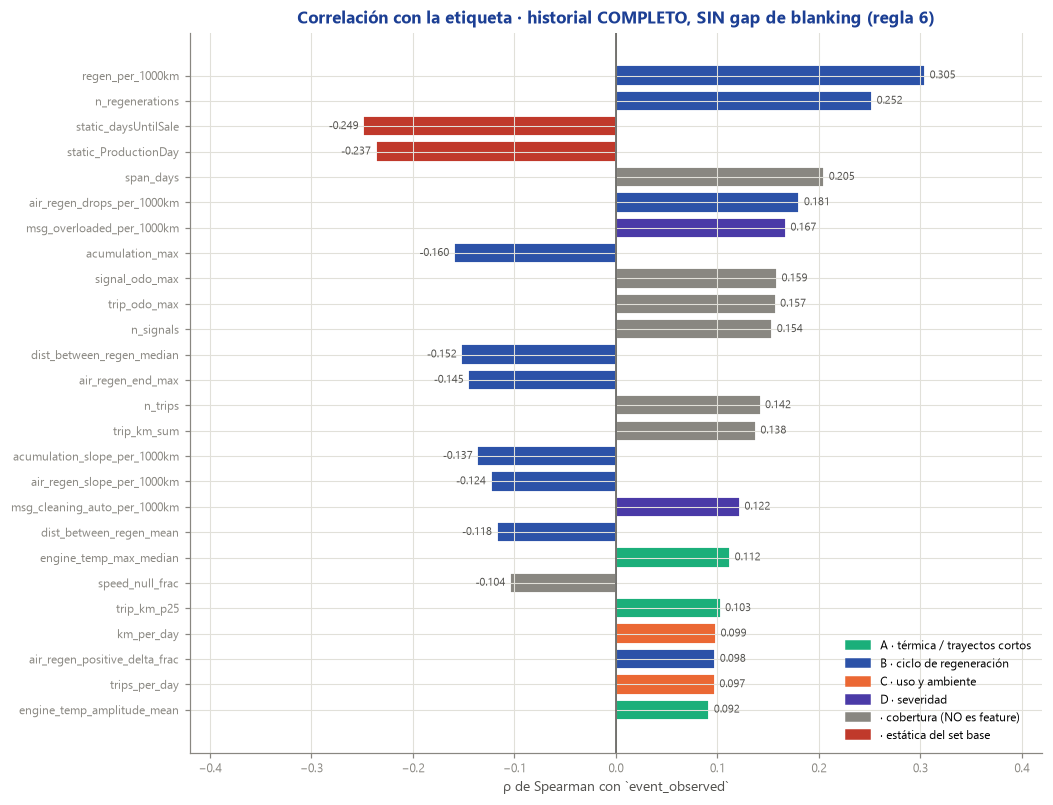

'                    variable                        familia     rho      p\n            regen_per_1000km      B · ciclo de regeneración  0.3046 0.0000\n             n_regenerations      B · ciclo de regeneración  0.2524 0.0000\n        static_daysUntilSale        · estática del set base -0.2490 0.0000\n        static_ProductionDay        · estática del set base -0.2368 0.0000\n                   span_days    · cobertura (NO es feature)  0.2052 0.0000\n  air_regen_drops_per_1000km      B · ciclo de regeneración  0.1808 0.0000\n   msg_overloaded_per_1000km                  D · severidad  0.1675 0.0000\n             acumulation_max      B · ciclo de regeneración -0.1596 0.0000\n              signal_odo_max    · cobertura (NO es feature)  0.1587 0.0000\n                trip_odo_max    · cobertura (NO es feature)  0.1573 0.0000\n                   n_signals    · cobertura (NO es feature)  0.1540 0.0000\n   dist_between_regen_median      B · ciclo de regeneración -0.1523 0.0000\n           

In [37]:
FAMILIA = {}
for c in ["short_trip_frac", "very_short_trip_frac", "below_regime_frac", "engine_temp_avg_median",
          "engine_temp_max_median", "engine_temp_amplitude_mean", "coolant_end_mean", "trip_km_median",
          "trip_km_p25"]:
    FAMILIA[c] = "A · térmica / trayectos cortos"
for c in ["acumulation_mean", "acumulation_median", "acumulation_max", "acumulation_high_frac",
          "acumulation_saturated_frac", "acumulation_slope_per_1000km", "air_regen_end_mean",
          "air_regen_end_max", "air_regen_saturated_frac", "air_regen_positive_delta_frac",
          "air_regen_slope_per_1000km", "air_regen_drops_per_1000km", "regen_per_1000km",
          "n_regenerations", "dist_between_regen_mean", "dist_between_regen_median",
          "dist_between_regen_slope_per_1000km"]:
    FAMILIA[c] = "B · ciclo de regeneración"
for c in ["speed_mean", "speed_median", "urban_trip_frac", "km_per_day", "trips_per_day",
          "hours_between_trips_median", "air_temp_avg_mean", "air_temp_min_mean", "refuel_frac",
          "fuel_start_mean"]:
    FAMILIA[c] = "C · uso y ambiente"
for c in ["oil_life_drop_per_1000km", "oil_life_start_mean", "air_filter_abnormal_frac",
          "msg_full_per_1000km", "msg_overloaded_per_1000km", "msg_cleaning_auto_per_1000km",
          "msg_over_limit_per_1000km", "msg_at_limit_per_1000km", "msg_normal_per_1000km"]:
    FAMILIA[c] = "D · severidad"
for c in ["n_trips", "n_signals", "span_days", "trip_odo_max", "signal_odo_max", "trip_km_sum",
          "signals_per_1000km", "speed_null_frac", "signal_odo_null_frac"]:
    FAMILIA[c] = "· cobertura (NO es feature)"
for c in ["static_daysUntilSale", "static_ProductionDay"]:
    FAMILIA[c] = "· estática del set base"

filas = []
for columna, familia in FAMILIA.items():
    serie = veh[columna]
    if serie.notna().sum() < 100 or serie.nunique() < 3:
        continue
    resultado = spearmanr(serie, veh["event_observed"], nan_policy="omit")
    filas.append({"variable": columna, "familia": familia, "rho": resultado.statistic,
                  "p": resultado.pvalue})
contra_etiqueta = pd.DataFrame(filas).sort_values("rho", key=abs, ascending=False)

COLOR_FAMILIA = {
    "A · térmica / trayectos cortos": CATEGORICAL[2],
    "B · ciclo de regeneración": CATEGORICAL[0],
    "C · uso y ambiente": CATEGORICAL[1],
    "D · severidad": CATEGORICAL[6],
    "· cobertura (NO es feature)": INK["muted"],
    "· estática del set base": ALERT_RED,
}
top = contra_etiqueta.head(26).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 8.5))
barras = ax.barh(top["variable"], top["rho"], color=[COLOR_FAMILIA[f] for f in top["familia"]],
                 edgecolor="white", linewidth=1.2)
ax.bar_label(barras, fmt="%.3f", fontsize=7, color=INK["secondary"], padding=3)
ax.axvline(0, color=INK["secondary"], lw=1.0)
ax.set_xlim(-0.42, 0.42)
ax.set_xlabel("ρ de Spearman con `event_observed`")
ax.set_title("Correlación con la etiqueta · historial COMPLETO, SIN gap de blanking (regla 6)",
             color=FORD_BLUE, fontweight="bold")
manijas = [mpl.patches.Patch(color=c, label=f) for f, c in COLOR_FAMILIA.items()]
ax.legend(handles=manijas, loc="lower right", fontsize=8)
plt.show()

contra_etiqueta.head(20).round(4).to_string(index=False)

### 7.3 · La alarma: `static_daysUntilSale` está en el set base

`daysUntilSale` y `ProductionDay` son las dos estáticas numéricas de
`features.static_columns` en `configs/data/panel_v1.yaml`, y las dos están entre
las cinco variables más correlacionadas con la etiqueta de todo el EDA —con signo
negativo: los vehículos con evento se produjeron y se vendieron antes—.

Sumado a §3.3, `daysUntilSale` deja de ser una covariable sospechosa y pasa a ser
otra cosa: **para el 79% de los vehículos con evento de dev es numéricamente igual
a `IdentificationDate`**, que *es* la etiqueta. No es una feature correlacionada
con el evento: es la fecha del evento con otro nombre.

ρ de Spearman con `event_observed`:
            variable                 familia     rho   p
static_daysUntilSale · estática del set base -0.2490 0.0
static_ProductionDay · estática del set base -0.2368 0.0


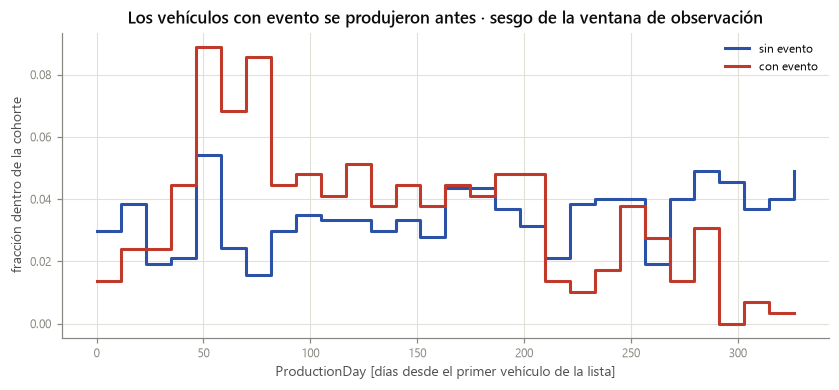


Tasa de eventos por quintil de ProductionDay (dev):
                  n  tasa_eventos
q                                
(0.999, 65.0]   174         0.408
(65.0, 128.0]   173         0.491
(128.0, 190.0]  174         0.379
(190.0, 263.0]  174         0.305
(263.0, 338.0]  169         0.101


In [38]:
print("ρ de Spearman con `event_observed`:")
print(contra_etiqueta[contra_etiqueta["familia"].eq("· estática del set base")].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(9, 3.6))
bins = np.linspace(0, veh["static_ProductionDay"].max(), 30)
for flag in COHORT_ORDER:
    side = veh[veh["event_observed"].eq(flag)]
    tasa, bordes = np.histogram(side["static_ProductionDay"], bins=bins)
    ax.step(bordes[:-1], tasa / tasa.sum(), where="post", color=COHORT_COLORS[flag], lw=2,
            label=COHORT_LABELS[flag])
ax.set_xlabel("ProductionDay [días desde el primer vehículo de la lista]")
ax.set_ylabel("fracción dentro de la cohorte")
ax.set_title("Los vehículos con evento se produjeron antes · sesgo de la ventana de observación")
ax.legend(loc="upper right")
plt.show()

print("\nTasa de eventos por quintil de ProductionDay (dev):")
print(veh.assign(q=pd.qcut(veh["static_ProductionDay"], 5))
      .groupby("q", observed=True)
      .agg(n=("event_observed", "size"), tasa_eventos=("event_observed", "mean"))
      .round(3).to_string())

**Recomendación para F2 (no es una decisión de este notebook):** auditar
`static_daysUntilSale` con el mismo criterio con el que se sacó `Engine`. Si el
79% de los positivos la tiene idéntica a la etiqueta, el modelo puede aprender la
fecha de venta y reportar un PR-AUC que no sobrevive al primer vehículo nuevo.
`ProductionDay` tiene el mismo problema por otra vía: la ventana de observación es
la misma para toda la flota, así que un vehículo producido tarde tuvo menos tiempo
de registrar un evento.

### 7.4 · Bonus: cuánto cae la correlación al blanquear la cola

Preview empírica del gap G: los mismos agregados de severidad recalculados usando
solo el primer 70% y el primer 80% del recorrido de cada vehículo.

  [ok] severity_scopes_dev          2592 filas ·  864 vehículos · 0 de test


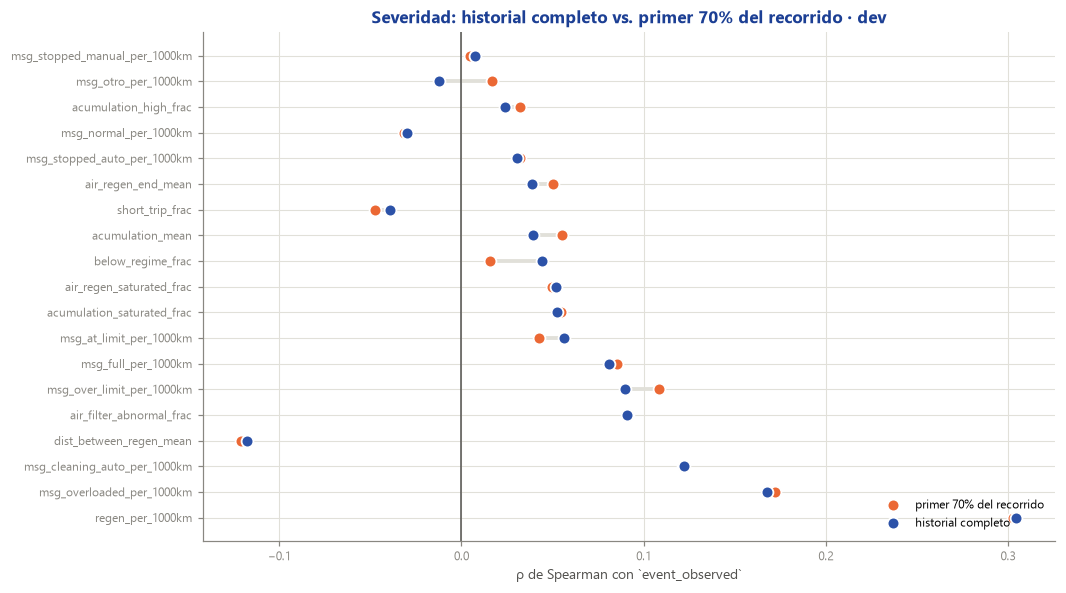

scope,p70,p80,full,caída p70 → full
variable,,,,
regen_per_1000km,0.3030,0.3050,0.3046,0.0016
msg_overloaded_per_1000km,0.1721,0.1743,0.1675,-0.0047
msg_cleaning_auto_per_1000km,0.1216,0.1224,0.1221,0.0006
dist_between_regen_mean,-0.1208,-0.1191,-0.1176,-0.0031
air_filter_abnormal_frac,0.0914,0.0935,0.0909,-0.0005
msg_over_limit_per_1000km,0.1085,0.0997,0.0900,-0.0185
msg_full_per_1000km,0.0854,0.0847,0.0808,-0.0047
msg_at_limit_per_1000km,0.0425,0.0521,0.0564,0.0140
acumulation_saturated_frac,0.0548,0.0569,0.0522,-0.0026


In [39]:
severidad = check_dev_only(cache["severity_scopes_dev"], "severity_scopes_dev") \
    .merge(veh[["vehicle_id", "event_observed"]], on="vehicle_id")

COLUMNAS_SEVERIDAD = [c for c in severidad.columns
                      if c.startswith("msg_") or c in {
                          "acumulation_mean", "acumulation_high_frac", "acumulation_saturated_frac",
                          "regen_per_1000km", "dist_between_regen_mean", "air_regen_end_mean",
                          "air_regen_saturated_frac", "air_filter_abnormal_frac",
                          "short_trip_frac", "below_regime_frac"}]
filas = []
for alcance, grupo in severidad.groupby("scope"):
    for columna in COLUMNAS_SEVERIDAD:
        if grupo[columna].notna().sum() < 100 or grupo[columna].nunique() < 3:
            continue
        filas.append({"scope": alcance, "variable": columna,
                      "rho": spearmanr(grupo[columna], grupo["event_observed"], nan_policy="omit").statistic})
truncado = pd.DataFrame(filas).pivot(index="variable", columns="scope", values="rho")
truncado = truncado[["p70", "p80", "full"]]
truncado["caída p70 → full"] = truncado["full"].abs() - truncado["p70"].abs()
orden = truncado["full"].abs().sort_values(ascending=False).index
truncado = truncado.loc[orden]

fig, ax = plt.subplots(figsize=(10, 6))
y = np.arange(len(truncado))
ax.hlines(y, truncado["p70"], truncado["full"], color=INK["grid"], lw=2.5)
ax.scatter(truncado["p70"], y, color=CATEGORICAL[1], s=60, zorder=3, edgecolor="white",
           linewidth=1.2, label="primer 70% del recorrido")
ax.scatter(truncado["full"], y, color=BLUE, s=60, zorder=3, edgecolor="white", linewidth=1.2,
           label="historial completo")
ax.axvline(0, color=INK["secondary"], lw=1.0)
ax.set_yticks(y, truncado.index)
ax.set_xlabel("ρ de Spearman con `event_observed`")
ax.set_title("Severidad: historial completo vs. primer 70% del recorrido · dev", color=FORD_BLUE,
             fontweight="bold")
ax.legend(loc="lower right")
plt.show()

truncado.round(4)

**Resultado inesperado, y hay que leerlo con cuidado: la correlación no cae.**
`regen_per_1000km` da ρ = 0,305 sobre el historial completo y 0,303 sobre el primer
70%. Ningún nivel de `Message` pierde más de 0,02.

Tres lecturas posibles, y la evidencia no separa entre ellas:

1. **La señal es de régimen de uso, no de la cola pre-evento.** Un vehículo que
   regenera más seguido por kilómetro lo hace desde el principio, así que
   blanquear la cola no le saca nada. Sería la mejor noticia posible para F2.
2. **La prueba no es la que hace falta.** Esta correlación es contra una etiqueta a
   nivel **vehículo**, no contra la etiqueta por punto de corte que F2 va a usar. El
   gap G protege contra memorizar los km previos a *un evento ubicado en el
   tiempo*; acá no hay punto de corte.
3. **El evento no está donde creemos.** Por §3.4, para el 79% de los positivos la
   fecha del evento cae con el odómetro casi en cero, así que "la cola" ni siquiera
   es el período previo al evento: es historial **posterior**. Truncarla no puede
   quitar leakage pre-evento porque en esos vehículos no hay historial pre-evento.

La prueba que realmente cierra esto necesita la posición del evento resuelta, y
eso es lo que §3.4 dejó abierto. **Hasta entonces, el gap G se mantiene por regla,
no por evidencia:** este resultado no lo justifica ni lo refuta.

## 8 · Análisis temporal

El eje de km es el del contrato, pero el calendario dice cómo se recolectaron los
datos, y eso explica varios de los sesgos de §7.

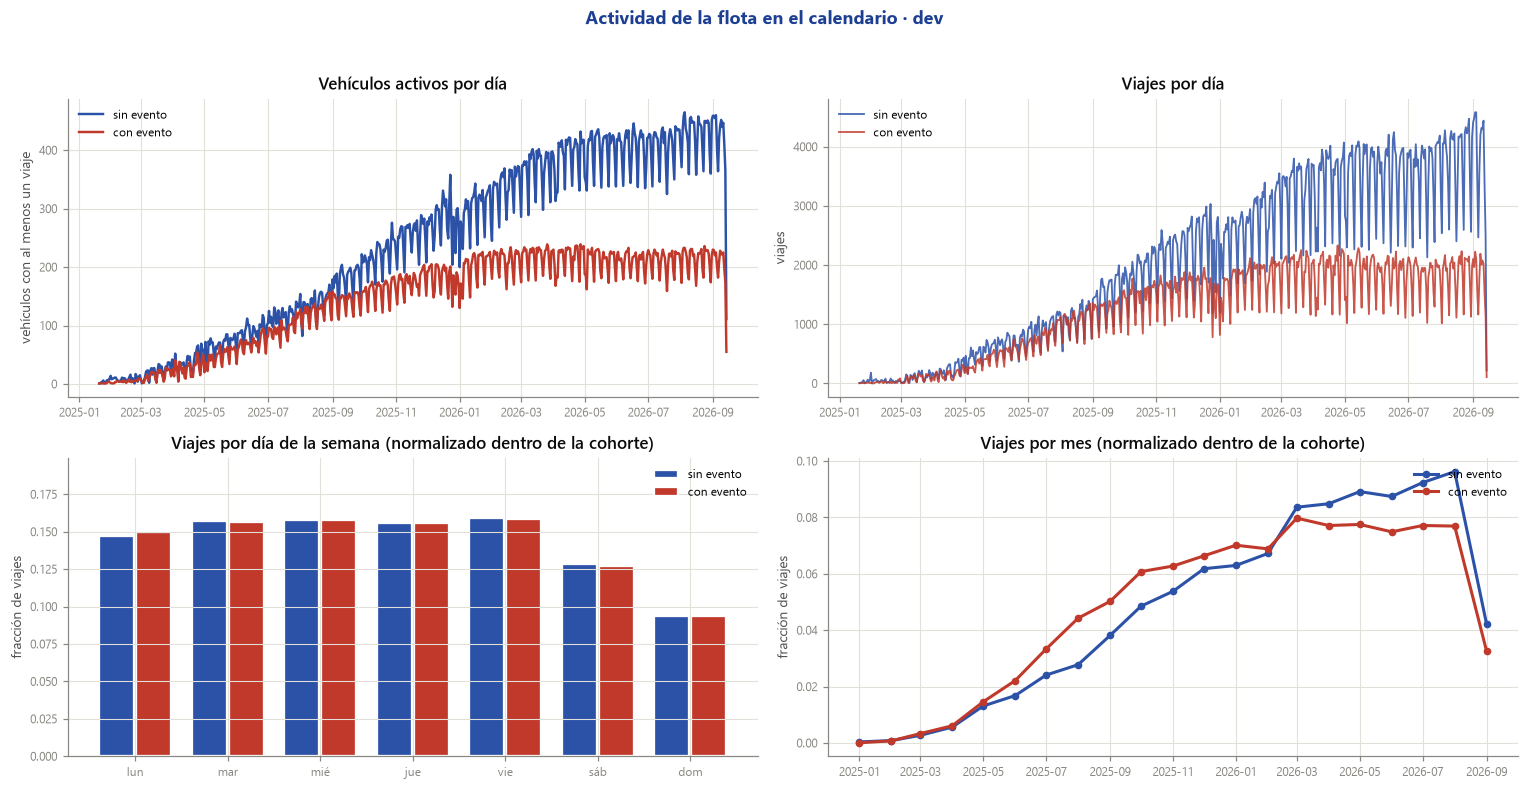

In [40]:
diario = cache["trips_daily_dev"].copy()
diario["date"] = pd.to_datetime(diario["date"])

fig, axes = plt.subplots(2, 2, figsize=(14, 7))

ax = axes[0, 0]
for flag in COHORT_ORDER:
    side = diario[diario["event_observed"].eq(flag)].sort_values("date")
    ax.plot(side["date"], side["n_vehicles"], color=COHORT_COLORS[flag], lw=1.6,
            label=COHORT_LABELS[flag])
ax.set_title("Vehículos activos por día")
ax.set_ylabel("vehículos con al menos un viaje")
ax.legend(loc="upper left")

ax = axes[0, 1]
for flag in COHORT_ORDER:
    side = diario[diario["event_observed"].eq(flag)].sort_values("date")
    ax.plot(side["date"], side["n_trips"], color=COHORT_COLORS[flag], lw=1.2, alpha=0.85,
            label=COHORT_LABELS[flag])
ax.set_title("Viajes por día")
ax.set_ylabel("viajes")
ax.legend(loc="upper left")

ax = axes[1, 0]
DIAS = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
semana = diario.groupby(["weekday", "event_observed"], observed=True)["n_trips"].sum().unstack()
semana = semana / semana.sum()
x = np.arange(7)
for i, flag in enumerate(COHORT_ORDER):
    if flag not in semana.columns:
        continue
    ax.bar(x + (i - 0.5) * 0.4, semana[flag], 0.38, color=COHORT_COLORS[flag],
           label=COHORT_LABELS[flag], edgecolor="white", linewidth=1.5)
ax.set_xticks(x, DIAS)
ax.set_title("Viajes por día de la semana (normalizado dentro de la cohorte)")
ax.set_ylabel("fracción de viajes")
ax.set_ylim(0, semana.to_numpy().max() * 1.25)
ax.legend(loc="upper right")

ax = axes[1, 1]
mensual = diario.groupby(["month", "event_observed"], observed=True)["n_trips"].sum().unstack()
mensual = mensual / mensual.sum()
for flag in COHORT_ORDER:
    if flag not in mensual.columns:
        continue
    ax.plot(mensual.index, mensual[flag], color=COHORT_COLORS[flag], lw=2, marker="o", ms=4,
            label=COHORT_LABELS[flag])
ax.set_title("Viajes por mes (normalizado dentro de la cohorte)")
ax.set_ylabel("fracción de viajes")
ax.legend(loc="upper right")

fig.suptitle("Actividad de la flota en el calendario · dev", y=1.02, color=FORD_BLUE, fontweight="bold")
fig.tight_layout()
plt.show()

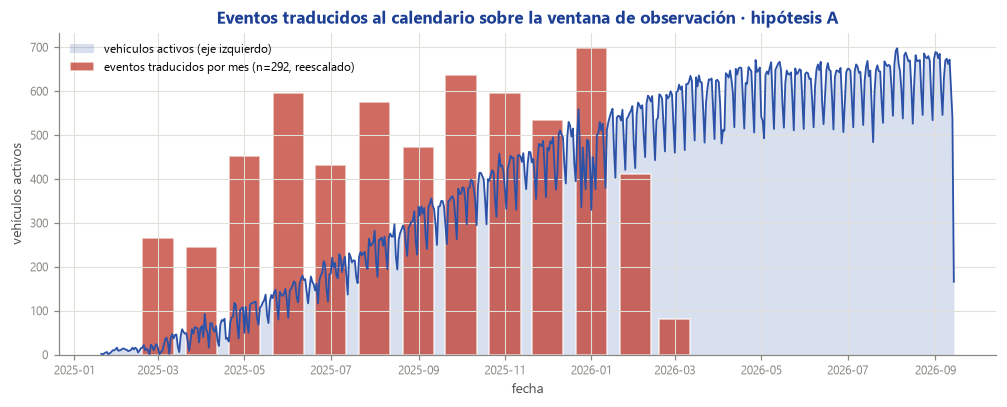

ventana de viajes observada: 2025-01-20 → 2026-09-14
eventos traducidos (A)     : 2025-03-07 → 2026-03-11
eventos fuera de la ventana: 0


In [41]:
# Distribución calendario de los eventos traducidos, contra la ventana de observación.
fig, ax = plt.subplots(figsize=(11, 3.8))
activos = diario.groupby("date")["n_vehicles"].sum()
ax.fill_between(activos.index, activos.to_numpy(), color=BLUE, alpha=0.18, lw=0,
                label="vehículos activos (eje izquierdo)")
ax.plot(activos.index, activos.to_numpy(), color=BLUE, lw=1.2)
ax.set_ylabel("vehículos activos")
ax.set_xlabel("fecha")

fechas_evento = pd.to_datetime(eventos["event_date"]).dropna()
conteo = fechas_evento.dt.tz_localize(None).dt.to_period("M").value_counts().sort_index()
escala = activos.max() / max(conteo.max(), 1)
ax.bar([p.to_timestamp() for p in conteo.index], conteo.to_numpy() * escala, width=22,
       color=ALERT_RED, alpha=0.75, edgecolor="white", linewidth=1.0,
       label=f"eventos traducidos por mes (n={len(fechas_evento)}, reescalado)")
ax.set_title("Eventos traducidos al calendario sobre la ventana de observación · hipótesis A",
             color=FORD_BLUE, fontweight="bold")
ax.legend(loc="upper left")
plt.show()

print(f"ventana de viajes observada: {diario['date'].min():%Y-%m-%d} → {diario['date'].max():%Y-%m-%d}")
print(f"eventos traducidos (A)     : {fechas_evento.min():%Y-%m-%d} → {fechas_evento.max():%Y-%m-%d}")
print(f"eventos fuera de la ventana: {int((fechas_evento < diario['date'].min()).sum() + (fechas_evento > diario['date'].max()).sum())}")

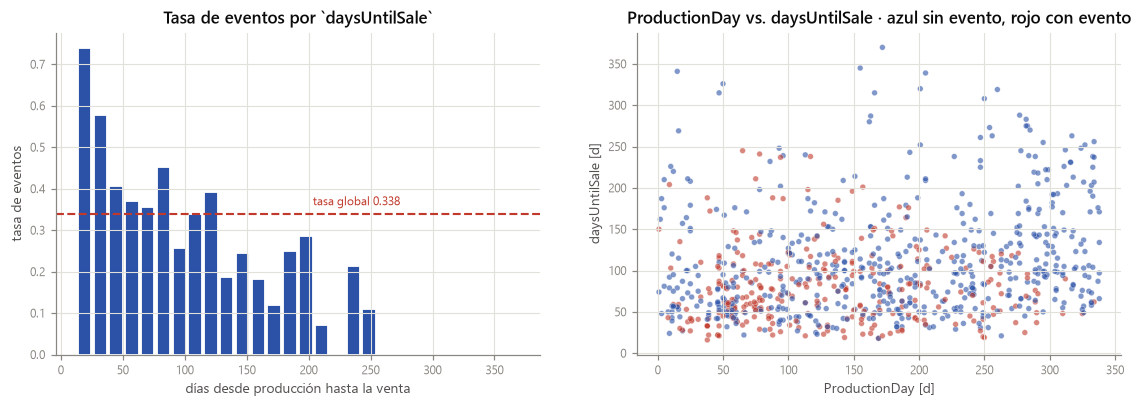

In [42]:
# `daysUntilSale` contra el evento, ya sabiendo lo de §3.3.
fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8))
ax = axes[0]
bins = np.linspace(0, veh["static_daysUntilSale"].max(), 30)
tasa = (veh.assign(b=pd.cut(veh["static_daysUntilSale"], bins))
        .groupby("b", observed=True)
        .agg(n=("event_observed", "size"), tasa=("event_observed", "mean")))
centros = [interv.mid for interv in tasa.index]
ax.bar(centros, tasa["tasa"], width=(bins[1] - bins[0]) * 0.85, color=BLUE, edgecolor="white",
       linewidth=1.2)
ax.axhline(veh["event_observed"].mean(), color=ALERT_RED, lw=1.4, ls="--")
ax.annotate(f"tasa global {veh['event_observed'].mean():.3f}",
            xy=(bins[-1] * 0.55, veh["event_observed"].mean()), xytext=(0, 6),
            textcoords="offset points", color=ALERT_RED, fontsize=8)
ax.set_title("Tasa de eventos por `daysUntilSale`")
ax.set_xlabel("días desde producción hasta la venta")
ax.set_ylabel("tasa de eventos")

ax = axes[1]
ax.scatter(veh["static_ProductionDay"], veh["static_daysUntilSale"],
           c=[COHORT_COLORS[int(f)] for f in veh["event_observed"]], s=14, alpha=0.6,
           edgecolor="white", linewidth=0.3)
ax.set_title("ProductionDay vs. daysUntilSale · azul sin evento, rojo con evento")
ax.set_xlabel("ProductionDay [d]")
ax.set_ylabel("daysUntilSale [d]")
plt.show()

## 9 · Factibilidad de las features del plan §4

Cruce entre lo que el plan propone (`plan-implementacion-ford.md` §4, con los
nombres ya reservados en `scripts/make_dummy.py::FEATURE_SPECS`) y lo que existe en
los CSV reales.

In [43]:
# El cruce vive en `scripts/build_eda_cache.py` (`PLAN_FEATURE_REQUIREMENTS` +
# `COLUMN_SUBSTITUTES`), así el dashboard muestra exactamente la misma tabla.
factibilidad = feature_feasibility(CONFIG)

print(factibilidad["veredicto"].value_counts().to_string())
print()
factibilidad[["feature", "familia", "columna_requerida", "veredicto", "sustituto"]]

veredicto
se puede construir                                                 21
se puede construir (con sustituto)                                  4
BLOQUEADA · no hay dato                                             4
parcial con sustituto                                               1
REQUIERE REDEFINIR · la columna está pero el contenido no sirve     1



,feature,familia,columna_requerida,veredicto,sustituto
0,feat_short_trip_frac_5km,A,OdometerTripStart/End,se puede construir,
1,feat_trips_below_regime_temp_frac,A,EngineTemperatureMax,se puede construir,
2,feat_engine_temp_avg_median,A,EngineTemperatureAvg,se puede construir,
3,feat_engine_temp_amplitude_mean,A,EngineTemperatureMin/Max,se puede construir,
4,feat_coolant_temp_end_mean,A,CoolantTemperatureEnd,se puede construir,
5,feat_trip_distance_median_km,A,OdometerTripStart/End,se puede construir,
6,feat_trip_distance_p25_km,A,OdometerTripStart/End,se puede construir,
7,feat_dpf_end_slope_per_1000km,B,DieselParticulateFilterEnd,se puede construir (con sustituto),AirRegenerationEnd (= signals.Acumulation en e...
8,feat_dpf_end_mean,B,DieselParticulateFilterEnd,se puede construir (con sustituto),AirRegenerationEnd (= signals.Acumulation en e...
9,feat_dpf_end_max,B,DieselParticulateFilterEnd,se puede construir (con sustituto),AirRegenerationEnd (= signals.Acumulation en e...


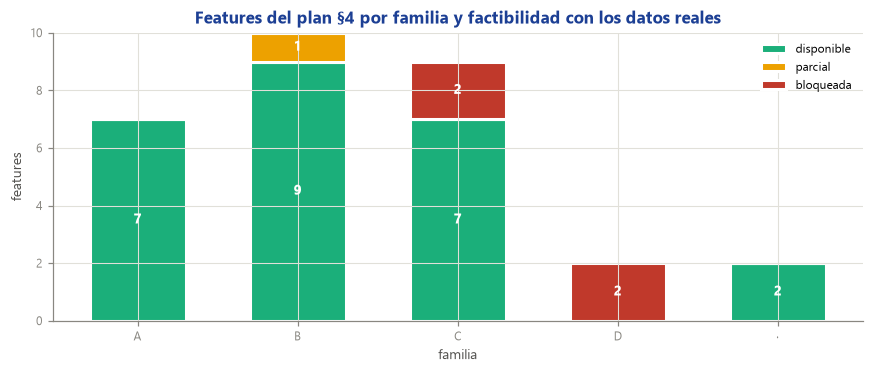

BLOQUEADAS (la columna no existe en el CSV bajo ningún nombre):
                          feature familia                    columna_requerida
            feat_elevation_mean_m       C       VehicleElevationRangeStart/End
           feat_elevation_range_m       C       VehicleElevationRangeStart/End
          feat_tire_pressure_mean       D TirePressure{LF,RF,LR,RR}{Start,End}
feat_tire_pressure_below_thr_frac       D TirePressure{LF,RF,LR,RR}{Start,End}


In [44]:
fig, ax = plt.subplots(figsize=(9.5, 3.4))
resumen = (factibilidad.groupby(["familia", "estado"]).size().unstack(fill_value=0)
           .reindex(columns=["disponible", "parcial", "bloqueada"], fill_value=0))
colores = {"disponible": CATEGORICAL[2], "parcial": CATEGORICAL[3], "bloqueada": ALERT_RED}
abajo = np.zeros(len(resumen))
for estado in resumen.columns:
    ax.bar(resumen.index, resumen[estado], 0.6, bottom=abajo, color=colores[estado], label=estado,
           edgecolor="white", linewidth=2)
    for x, (valor, base) in enumerate(zip(resumen[estado], abajo)):
        if valor:
            ax.text(x, base + valor / 2, str(int(valor)), ha="center", va="center", color="white",
                    fontsize=9, fontweight="bold")
    abajo = abajo + resumen[estado].to_numpy()
ax.set_title("Features del plan §4 por familia y factibilidad con los datos reales", color=FORD_BLUE,
             fontweight="bold")
ax.set_ylabel("features")
ax.set_xlabel("familia")
ax.legend(loc="upper right")
plt.show()

print("BLOQUEADAS (la columna no existe en el CSV bajo ningún nombre):")
print(factibilidad.loc[factibilidad["veredicto"].str.startswith("BLOQUEADA"),
                       ["feature", "familia", "columna_requerida"]].to_string(index=False))

**Resultado.**

- **Familias A y C (menos elevación), y D (menos presión de neumáticos): completas.**
  Todas sus columnas existen en `trips`.
- **Familia B: completa también**, gracias a §6.4. `feat_dpf_*` se construye con
  `AirRegenerationStart/End` en vez de `DieselParticulateFilter*`.
  `feat_manual_regen_per_1000km` queda parcial: el hollín de regeneración manual no
  está, pero los niveles `Cleanning/Stopped Cleanning Manually Air Filter` de
  `Message`/`AirFilter*` marcan el evento (son raros: los ven 31 y 4 vehículos de
  dev respectivamente, así que como tasa va a ser casi siempre cero).
- **`feat_oil_life_drop_per_1000km` hay que redefinirla** (§5.3): la columna existe
  y está completa, pero su delta intra-viaje es exactamente cero en el 100% de los
  viajes.
- **Bloqueadas, sin sustituto posible: 4 features.** `feat_elevation_mean_m` y
  `feat_elevation_range_m` (familia C) y `feat_tire_pressure_mean` y
  `feat_tire_pressure_below_thr_frac` (familia D). Las columnas de elevación, GPS y
  presión de neumáticos **no están en el archivo**, y no hay nada que las
  aproxime: sin GPS tampoco se puede inferir altitud.

La elevación era, según el plan, la variable "ligada directamente al ingreso de
oxígeno que menciona el título del desafío". Ese ángulo no se puede explorar con
estos datos.

## 10 · Síntesis para quien implemente F2

### Lo que desbloquea

1. **El DPF existe, con otro nombre y en las dos tablas** (§6.4).
   `trips.AirRegenerationStart/End` coincide exactamente con `signals.Acumulation`
   en el 99,8% de los pares alineados, y `trips.AirFilterStart/End` con
   `signals.Message` en el 99,98%. La familia B del plan §4 se puede construir
   entera, y a nivel viaje —que es mejor grano que el de `signals` para cortar
   ventanas—. `docs/memoria/f1-datos-reales.md` decía "no hay columna de DPF";
   hay dos.
2. **Priorizar la familia B.** `regen_per_1000km` es el agregado que más separa
   cohortes de todo el EDA (mediana 2,61 vs 1,80; `prob_supera` 0,66), seguido por
   la tasa de `Air Filter Overloaded`. Las familias A y C, medidas sobre el
   historial completo, casi no separan (§5.2) — lo cual no las descarta a nivel
   ventana, pero sí dice por dónde empezar.
3. **El anclaje temporal se sostiene en dev** (§3.1): IQR de 0 días. La mecánica de
   traducción funciona.

### Lo que bloquea o cambia el alcance

4. **La posición del evento sobre el eje de km es inutilizable para el 79% de los
   positivos** (§3.3-3.4). `IdentificationDate == daysUntilSale` exactamente en 231
   de los 292 vehículos con evento de dev, y bajo la lectura literal del anexo 7.3
   esos eventos caen con 13 km de odómetro y el 2,3% del historial por delante.
   **Esto hay que resolverlo antes de definir W, G, H y Δ**, porque sin posición de
   evento no hay etiqueta por punto de corte. Tres salidas posibles, ninguna
   gratis: preguntar a Ford; restringir las filas etiquetadas a los 61 vehículos
   con fecha discriminante; o pasar a un objetivo a nivel vehículo.
5. **Cuatro features del plan quedan sin datos y una está mal especificada** (§9,
   §5.3): las dos de elevación
   (familia C) y las dos de presión de neumáticos (familia D). Las columnas no
   existen en el CSV bajo ningún nombre, junto con GPS, autonomía de combustible y
   hollín de regeneración manual. Hay que sacarlas de `FEATURE_SPECS` o dejarlas
   documentadas como no construibles. Y `feat_oil_life_drop_per_1000km` se redefine
   como pendiente del nivel contra odómetro: el delta intra-viaje es cero siempre.
6. **`static_daysUntilSale` es un riesgo de leakage de primer orden** (§7.3), y
   está en el set base de `panel_v1.yaml`. Para el 79% de los positivos es
   numéricamente igual a la etiqueta. `static_ProductionDay` arrastra el mismo
   sesgo de ventana de observación por otra vía.

### Lo que hay que manejar

7. **El 11% de `OdometerValue` nulo está concentrado, no repartido** (§4): la
   mediana por vehículo es 0,00% y unos pocos vehículos tienen entre el 66% y el
   99% de sus señales sin odómetro. Descartar esas filas no sesga a la flota, pero
   deja a ese puñado sin ninguna feature de `signals`.
8. **`signals` trae ~1,1% de filas exactamente repetidas** que no son clones
   (85.724 en dev). Toda tasa por 1.000 km sale inflada si no se deduplica antes de
   agregar. El cache del EDA ya lo hace.
9. **Las variables de cobertura correlacionan con la etiqueta** (§7.2):
   `span_days` ρ=0,21, `trip_odo_max` ρ=0,16. Es sesgo de muestreo, no física. Es
   exactamente lo que `sampling.match_healthy_cut_distribution` de
   `panel_v1.yaml` tiene que neutralizar.
10. **El gap G se mantiene por regla, no por evidencia** (§7.4). Truncar la cola
    del historial no baja la correlación, pero esa prueba no es la que corresponde:
    necesita la posición del evento resuelta (punto 4). No hay excusa para sacar el
    gap.

### Lo que queda como hipótesis abierta

- Que `AirRegenerationStart/End` **sea** el `DieselParticulateFilterStart/End` del
  anexo 7.1. Que es la misma variable que `Acumulation` está medido; que ambas sean
  el DPF renombrado es la explicación que mejor encaja, sin confirmación de Ford.
  La escala llega a 95, no a 100, lo que sugiere un tope de reporte.
- Que `IdentificationDate` deba leerse como días desde la **venta** (hipótesis B de
  §3.4). Los números quedan mejor, pero el anexo 7.3 dice "días desde producción".
  Elegirla porque queda mejor es exactamente lo que el holdout existe para evitar.

### Y lo que no cambió

Ningún vehículo de test entró en ningún cómputo de este notebook. La guarda
`check_dev_only()` corrió sobre cada tabla y sobre cada tabla derivada.

In [45]:
# Cierre: la guarda, una vez más, sobre todo lo que se tocó.
print("Verificación final de la restricción dev-only:\n")
for nombre, tabla in cache.items():
    if isinstance(tabla, pd.DataFrame) and "vehicle_id" in tabla.columns:
        check_dev_only(tabla, nombre)
check_dev_only(veh, "vehicle_matrix")
check_dev_only(eventos, "eventos (con evento)")
check_dev_only(severidad, "severity + etiqueta")
check_dev_only(alineado, "alineación trips↔signals")

print(f"\nvehículos de test declarados en el holdout : {len(TEST_VEHICLES)}")
print(f"vehículos de test tocados en el notebook   : 0")
print(f"universo efectivo del EDA                  : {veh['vehicle_id'].nunique()} de {len(DEV_VEHICLES)} de dev")

Verificación final de la restricción dev-only:

  [ok] vehicles_dev                  864 filas ·  864 vehículos · 0 de test
  [ok] trips_agg_dev                 864 filas ·  864 vehículos · 0 de test
  [ok] signals_agg_dev               864 filas ·  864 vehículos · 0 de test
  [ok] severity_scopes_dev          2592 filas ·  864 vehículos · 0 de test
  [ok] message_counts_dev           7225 filas ·  864 vehículos · 0 de test
  [ok] airfilter_counts_dev         4188 filas ·  864 vehículos · 0 de test
  [ok] trips_sample_dev           250000 filas ·  864 vehículos · 0 de test
  [ok] signals_sample_dev         250000 filas ·  864 vehículos · 0 de test
  [ok] probe_trips_dev             17074 filas ·    8 vehículos · 0 de test
  [ok] probe_signals_dev           63659 filas ·    8 vehículos · 0 de test
  [ok] vehicle_matrix                864 filas ·  864 vehículos · 0 de test
  [ok] eventos (con evento)          292 filas ·  292 vehículos · 0 de test
  [ok] severity + etiqueta          2592